# TCGA Classification Figures

Thin cached-results notebook for the per-cancer TCGA feature-classification workflow. It reads saved `classification_results.tsv` outputs only, renders figures for every saved cohort, and then builds equal-weight cross-cancer summaries.

In [1]:
from contextlib import nullcontext
from pathlib import Path
from types import SimpleNamespace
import importlib.util
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap, Normalize
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display
from IPython.utils.capture import capture_output
from PyComplexHeatmap import ClusterMapPlotter, HeatmapAnnotation, anno_simple

from colors import (
    ANNOTATION_COLORS,
    FEATURE_SET_COLORS,
    HEATMAP_COLOR_SCALES,
    NEUTRAL_COLORS,
    get_categorical_color_map,
    ordered_palette,
)


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if candidate.name == "20260624_methylseg" and (candidate / "repo_paths.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the 20260624_methylseg project root from the current working directory.")


def discover_saved_cohorts(results_dir: Path) -> list[str]:
    cohort_ids = []
    for cohort_dir in sorted(path for path in results_dir.iterdir() if path.is_dir()):
        if any(task_dir.is_dir() and (task_dir / "classification_results.tsv").exists() for task_dir in cohort_dir.glob("n_features_*")):
            cohort_ids.append(cohort_dir.name)
    return cohort_ids


def save_current_figure(path: Path, fig: plt.Figure | None = None, *, close: bool = True) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig = plt.gcf() if fig is None else fig
    fig.savefig(path, dpi=160, bbox_inches="tight", pad_inches=0.2)
    if close:
        plt.close(fig)
    return path


def capture_plot(plotter, *args, **kwargs):
    original_show = plt.show
    plt.show = lambda *show_args, **show_kwargs: None
    try:
        with capture_output():
            result = plotter(*args, **kwargs)
    finally:
        plt.show = original_show
    return result, plt.gcf()


def display_saved_figure(path: Path) -> None:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Expected saved figure does not exist: {path}")
    display(Image(filename=str(path)))


def display_note(message: str) -> None:
    display(Markdown(message))


def relabel_current_figure(title: str, *, y: float, rect=None, fontsize: int = 16, fig: plt.Figure | None = None) -> None:
    fig = plt.gcf() if fig is None else fig
    fig.suptitle(title, y=y, fontsize=fontsize)
    if rect is None:
        fig.tight_layout()
    else:
        fig.tight_layout(rect=rect)


def format_cohort_label(cohort_id: str) -> str:
    return str(cohort_id).removeprefix("TCGA-")


def summarize_across_cohorts(cohort_summaries: pd.DataFrame, feature_sizes: list[int]) -> pd.DataFrame:
    plot_summary = cohort_summaries.loc[
        cohort_summaries["n_features"].isin(feature_sizes)
    ].copy()
    if plot_summary.empty:
        raise ValueError("No cohort summaries were available for the requested feature sizes.")

    aggregate_summary = (
        plot_summary
        .groupby(["feature_set", "n_features", "metric"], as_index=False)
        .agg(
            mean=("mean", "mean"),
            std=("mean", "std"),
            n_cohorts=("cohort_id", "nunique"),
        )
    )
    aggregate_summary["std"] = aggregate_summary["std"].fillna(0.0)
    aggregate_summary["sem"] = aggregate_summary["std"] / np.sqrt(aggregate_summary["n_cohorts"].clip(lower=1))
    return aggregate_summary.sort_values(["metric", "feature_set", "n_features"]).reset_index(drop=True)


def plot_metric_summary_from_table(summary: pd.DataFrame, metrics, feature_set_order, palette, feature_set_labels, *, x_log_scale=False, title="Classification performance across feature-set sizes", subplot_title_suffix=None, title_size: int = 18, label_size: int = 14, tick_size: int = 11, figure_title_size: int = 16, legend_font_size: int | None = None):
    metric_titles = {
        "balanced_accuracy": "Balanced accuracy",
        "average_precision": "Average precision",
        "macro_f1": "Macro F1 score",
        "mcc": "Matthews correlation coefficient",
        "roc_auc": "ROC AUC",
    }

    plotted_metrics = [metric for metric in metrics if metric in summary["metric"].unique()]
    n_cols = 2
    n_rows = int(np.ceil(len(plotted_metrics) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, metric in zip(axes, plotted_metrics):
        metric_summary = summary.loc[summary["metric"] == metric].copy()
        for feature_set in feature_set_order:
            feature_df = metric_summary.loc[
                metric_summary["feature_set"] == feature_set
            ].sort_values("n_features")
            if feature_df.empty:
                continue

            x = feature_df["n_features"].to_numpy(dtype=float)
            y = feature_df["mean"].to_numpy(dtype=float)
            sem = feature_df["sem"].fillna(0.0).to_numpy(dtype=float)
            color = palette.get(feature_set)
            ax.plot(
                x,
                y,
                marker="o",
                linewidth=2,
                color=color,
                label=feature_set_labels.get(feature_set, feature_set),
            )
            ax.fill_between(x, y - sem, y + sem, color=color, alpha=0.15)

        metric_title = metric_titles.get(metric, metric.replace("_", " ").title())
        if subplot_title_suffix:
            metric_title = f"{metric_title} - {subplot_title_suffix}"
        ax.set_title(metric_title, fontsize=title_size)
        ax.set_xlabel("Number of regions", fontsize=label_size)
        ax.set_ylabel("Score", fontsize=label_size)
        ax.tick_params(axis="x", labelbottom=True, labelsize=tick_size)
        ax.tick_params(axis="y", labelsize=tick_size)
        if x_log_scale:
            ax.set_xscale("log")
        if metric == "mcc":
            ax.set_ylim(-1.05, 1.05)
        else:
            ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.25)

    for ax in axes[len(plotted_metrics):]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))
    fig.suptitle(title, y=0.99, fontsize=figure_title_size)
    fig.legend(
        unique_labels.values(),
        unique_labels.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=min(len(unique_labels), 3),
        frameon=False,
        prop={"size": legend_font_size or tick_size},
    )
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()


def build_aggregate_box_data(results: pd.DataFrame, n_features: int, metrics, feature_set_order, feature_set_labels):
    metric_columns = [metric for metric in metrics if metric in results.columns]
    box_data = results.loc[
        results["n_features"] == int(n_features),
        ["cohort_id", "feature_set", "n_features", *metric_columns],
    ].copy()
    if box_data.empty:
        raise ValueError(f"No cohort results were found for n_features={int(n_features)}.")

    box_long = box_data.melt(
        id_vars=["cohort_id", "feature_set", "n_features"],
        value_vars=metric_columns,
        var_name="metric",
        value_name="score",
    )
    box_long["feature_set"] = pd.Categorical(box_long["feature_set"], categories=feature_set_order, ordered=True)
    box_long["display_feature_set"] = box_long["feature_set"].map(lambda feature_set: feature_set_labels.get(feature_set, feature_set))
    box_long["display_feature_set"] = pd.Categorical(
        box_long["display_feature_set"],
        categories=[feature_set_labels.get(feature_set, feature_set) for feature_set in feature_set_order],
        ordered=True,
    )
    return box_long.sort_values(["metric", "feature_set", "cohort_id"]).reset_index(drop=True)


def plot_aggregate_box_data(box_long: pd.DataFrame, metrics, feature_set_order, palette, feature_set_labels, *, n_features: int, subplot_title_suffix=None, title_size: int = 18, label_size: int = 14, tick_size: int = 11, figure_title_size: int = 16):
    display_feature_set_order = [feature_set_labels.get(feature_set, feature_set) for feature_set in feature_set_order]
    display_palette = {feature_set_labels.get(feature_set, feature_set): color for feature_set, color in palette.items()}
    metric_titles = {
        "balanced_accuracy": "Balanced accuracy",
        "average_precision": "Average precision",
        "macro_f1": "Macro F1 score",
        "mcc": "Matthews correlation coefficient",
        "roc_auc": "ROC AUC",
    }

    plotted_metrics = [metric for metric in metrics if metric in box_long["metric"].unique()]
    n_cols = 2
    n_rows = int(np.ceil(len(plotted_metrics) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows), sharey=False)
    axes = np.atleast_1d(axes).ravel()
    rng = np.random.default_rng(42)

    for ax, metric in zip(axes, plotted_metrics):
        metric_df = box_long.loc[box_long["metric"] == metric].copy()
        positions = np.arange(1, len(display_feature_set_order) + 1)
        violin_data = []
        violin_positions = []
        for position, display_feature_set in zip(positions, display_feature_set_order):
            scores = metric_df.loc[
                metric_df["display_feature_set"] == display_feature_set,
                "score",
            ].dropna().to_numpy(dtype=float)
            if scores.size == 0:
                continue
            violin_data.append(scores)
            violin_positions.append(position)

            x_offsets = rng.uniform(0.04, 0.18, size=scores.size)
            ax.scatter(
                np.full(scores.size, position, dtype=float) + x_offsets,
                scores,
                color=NEUTRAL_COLORS["black"],
                alpha=0.45,
                s=12,
                linewidths=0,
                zorder=3,
            )
            median_score = float(np.median(scores))
            ax.plot(
                [position - 0.18, position - 0.02],
                [median_score, median_score],
                color=NEUTRAL_COLORS["black"],
                linewidth=1.8,
                solid_capstyle="round",
                zorder=4,
            )

        if violin_data:
            violin_parts = ax.violinplot(
                violin_data,
                positions=violin_positions,
                widths=0.32,
                showmeans=False,
                showmedians=False,
                showextrema=False,
                side="low",
            )
            for body, position in zip(violin_parts["bodies"], violin_positions):
                display_feature_set = display_feature_set_order[position - 1]
                color = display_palette.get(display_feature_set)
                body.set_facecolor(color)
                body.set_edgecolor(color)
                body.set_alpha(0.65)

        metric_title = metric_titles.get(metric, metric.replace("_", " ").title())
        if subplot_title_suffix:
            metric_title = f"{metric_title} - {subplot_title_suffix}"
        ax.set_title(metric_title, fontsize=title_size)
        ax.set_xlabel("Feature set", fontsize=label_size)
        ax.set_ylabel("Score", fontsize=label_size)
        ax.set_xticks(positions)
        ax.set_xticklabels(display_feature_set_order)
        ax.tick_params(axis="x", rotation=25, labelsize=tick_size)
        ax.tick_params(axis="y", labelsize=tick_size)
        if metric == "mcc":
            ax.set_ylim(-1.05, 1.05)
        else:
            ax.set_ylim(-0.05, 1.05)
        ax.grid(True, axis="y", alpha=0.25)

    for ax in axes[len(plotted_metrics):]:
        ax.axis("off")

    fig.suptitle(f"All TCGA cohorts: per-run classification scores for {int(n_features)} regions", y=1.02, fontsize=figure_title_size)
    fig.tight_layout()
    plt.show()


def list_available_fold_choices(
    fold_predictions: pd.DataFrame,
    *,
    n_features: int,
    feature_draw: int = 0,
    required_feature_sets: list[str] | tuple[str, ...] | None = None,
    only_complete: bool = False,
) -> pd.DataFrame:
    candidate = fold_predictions.loc[
        (fold_predictions["n_features"] == int(n_features))
        & (fold_predictions["feature_draw"] == int(feature_draw))
    ].copy()
    if candidate.empty:
        raise ValueError(
            f"No fold predictions were found for n_features={int(n_features)} and feature_draw={int(feature_draw)}."
        )

    if required_feature_sets is None:
        required_feature_sets = []
    required_feature_sets = [str(feature_set) for feature_set in required_feature_sets]

    fold_choices = (
        candidate.groupby(["fold_key", "split", "repeat", "fold"], as_index=False)["feature_set"]
        .agg(lambda values: sorted({str(value) for value in values}))
        .sort_values(["split", "repeat", "fold"])
        .reset_index(drop=True)
    )
    fold_choices["n_available_feature_sets"] = fold_choices["feature_set"].map(len)
    fold_choices["missing_feature_sets"] = fold_choices["feature_set"].map(
        lambda available: [feature_set for feature_set in required_feature_sets if feature_set not in available]
    )
    fold_choices["has_all_feature_sets"] = fold_choices["missing_feature_sets"].map(lambda missing: len(missing) == 0)
    if only_complete:
        fold_choices = fold_choices.loc[fold_choices["has_all_feature_sets"]].copy()
        if fold_choices.empty:
            raise ValueError(
                "No folds contained the full requested feature-set panel for the confusion matrix."
            )
    fold_choices.insert(0, "selection_index", np.arange(len(fold_choices), dtype=int))
    return fold_choices



def select_fold_predictions(
    fold_predictions: pd.DataFrame,
    *,
    n_features: int,
    feature_draw: int = 0,
    fold_key: str | None = None,
    split: int | None = None,
    repeat: int | None = None,
    fold: int | None = None,
    selection_index: int | None = None,
    random_seed: int | None = None,
    required_feature_sets: list[str] | tuple[str, ...] | None = None,
    prefer_complete: bool = True,
) -> tuple[pd.DataFrame, dict]:
    candidate = fold_predictions.loc[
        (fold_predictions["n_features"] == int(n_features))
        & (fold_predictions["feature_draw"] == int(feature_draw))
    ].copy()
    if candidate.empty:
        raise ValueError(
            f"No fold predictions were found for n_features={int(n_features)} and feature_draw={int(feature_draw)}."
        )

    fold_choices = list_available_fold_choices(
        fold_predictions,
        n_features=n_features,
        feature_draw=feature_draw,
        required_feature_sets=required_feature_sets,
    )
    selected_choices = fold_choices.copy()

    if fold_key is not None:
        selected_choices = selected_choices.loc[selected_choices["fold_key"] == str(fold_key)].copy()
    if split is not None:
        selected_choices = selected_choices.loc[selected_choices["split"] == int(split)].copy()
    if repeat is not None:
        selected_choices = selected_choices.loc[selected_choices["repeat"] == int(repeat)].copy()
    if fold is not None:
        selected_choices = selected_choices.loc[selected_choices["fold"] == int(fold)].copy()

    if selection_index is not None:
        selected_choices = selected_choices.loc[
            selected_choices["selection_index"] == int(selection_index)
        ].copy()

    explicit_selection = any(
        value is not None
        for value in (fold_key, split, repeat, fold, selection_index)
    )
    if explicit_selection:
        if selected_choices.empty:
            raise ValueError(
                "No fold matched the requested confusion-matrix selection. "
                "Inspect `available_brca_confusion_splits` for valid choices."
            )
        if len(selected_choices) != 1:
            raise ValueError(
                "The requested confusion-matrix selection matched multiple folds. "
                "Specify `fold_key` or `selection_index` to make it unique."
            )
        selected_fold = selected_choices.iloc[0]
        if required_feature_sets is not None and not bool(selected_fold["has_all_feature_sets"]):
            missing = ", ".join(selected_fold["missing_feature_sets"])
            raise ValueError(
                "The requested fold does not contain predictions for the full confusion-matrix panel. "
                f"Missing feature sets: {missing}."
            )
    else:
        default_choices = fold_choices.copy()
        if prefer_complete and required_feature_sets is not None:
            complete_choices = default_choices.loc[default_choices["has_all_feature_sets"]].copy()
            if not complete_choices.empty:
                default_choices = complete_choices
        if random_seed is not None:
            rng = np.random.default_rng(random_seed)
            selected_fold = default_choices.iloc[int(rng.integers(len(default_choices)))]
        else:
            selected_fold = default_choices.iloc[0]

    selected_predictions = candidate.loc[
        candidate["fold_key"] == selected_fold["fold_key"]
    ].copy().sort_values(["sample_id", "feature_set"]).reset_index(drop=True)
    selection = {
        "selection_index": int(selected_fold["selection_index"]),
        "fold_key": str(selected_fold["fold_key"]),
        "split": int(selected_fold["split"]),
        "repeat": int(selected_fold["repeat"]),
        "fold": int(selected_fold["fold"]),
        "n_features": int(n_features),
        "feature_draw": int(feature_draw),
        "has_all_feature_sets": bool(selected_fold["has_all_feature_sets"]),
        "missing_feature_sets": list(selected_fold["missing_feature_sets"]),
        "n_available_feature_sets": int(selected_fold["n_available_feature_sets"]),
    }
    return selected_predictions, selection



def select_random_fold_predictions(
    fold_predictions: pd.DataFrame,
    *,
    n_features: int,
    feature_draw: int = 0,
    random_seed: int = 42,
) -> tuple[pd.DataFrame, dict]:
    return select_fold_predictions(
        fold_predictions,
        n_features=n_features,
        feature_draw=feature_draw,
        random_seed=random_seed,
    )


def plot_confusion_matrix_grid(
    fold_predictions: pd.DataFrame,
    *,
    feature_set_order,
    feature_set_labels,
    figure_title: str,
    title_size: int = 18,
    label_size: int = 14,
    tick_size: int = 11,
    figure_title_size: int = 16,
) -> tuple[plt.Figure, np.ndarray]:
    available_feature_sets = [
        feature_set for feature_set in feature_set_order
        if feature_set in set(fold_predictions["feature_set"].dropna().astype(str))
    ]
    if not available_feature_sets:
        raise ValueError("No feature sets were available to plot confusion matrices.")

    n_cols = 3
    n_rows = int(np.ceil(len(available_feature_sets) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.2 * n_rows), sharex=False, sharey=False)
    axes = np.atleast_1d(axes).ravel()
    class_labels = ["Normal", "Tumor"]

    for ax, feature_set in zip(axes, available_feature_sets):
        feature_df = fold_predictions.loc[
            fold_predictions["feature_set"] == feature_set,
            ["y_true", "y_pred"],
        ].copy()
        confusion = pd.crosstab(feature_df["y_true"], feature_df["y_pred"]).reindex(
            index=[0, 1], columns=[0, 1], fill_value=0
        )
        normalized = confusion.div(confusion.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
        annotations = np.empty(confusion.shape, dtype=object)
        for row_idx in range(confusion.shape[0]):
            for col_idx in range(confusion.shape[1]):
                count = int(confusion.iat[row_idx, col_idx])
                frac = float(normalized.iat[row_idx, col_idx])
                annotations[row_idx, col_idx] = f"{count}\n{frac:.1%}"

        sns.heatmap(
            normalized,
            annot=annotations,
            fmt="",
            cmap=LinearSegmentedColormap.from_list(
            "tcga_confusion_white_to_blue",
            HEATMAP_COLOR_SCALES["confusion_white_to_blue"],
        ),
            cbar=False,
            vmin=0.0,
            vmax=1.0,
            linewidths=0.8,
            linecolor=NEUTRAL_COLORS["white"],
            square=True,
            ax=ax,
        )
        ax.set_title(feature_set_labels.get(feature_set, feature_set), fontsize=title_size)
        ax.set_xlabel("Predicted label", fontsize=label_size)
        ax.set_ylabel("True label", fontsize=label_size)
        ax.set_xticklabels(class_labels, rotation=0, fontsize=tick_size)
        ax.set_yticklabels(class_labels, rotation=0, fontsize=tick_size)
        ax.tick_params(axis="both", length=0)

    for ax in axes[len(available_feature_sets):]:
        ax.axis("off")

    fig.suptitle(figure_title, y=0.99, fontsize=figure_title_size)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return fig, axes


def resolve_metric_column_name(metric: str, available_columns) -> str:
    metric_name = str(metric).strip()
    metric_aliases = {
        "f1": "macro_f1",
    }
    metric_name = metric_aliases.get(metric_name, metric_name)
    available_metrics = {str(column) for column in available_columns}
    if metric_name not in available_metrics:
        available = ", ".join(sorted(available_metrics))
        raise ValueError(f"Unknown metric {metric!r}. Available metrics: {available}")
    return metric_name



def get_classification_metric_title(metric: str) -> str:
    metric_titles = {
        "balanced_accuracy": "Balanced accuracy",
        "average_precision": "Average precision",
        "macro_f1": "Macro F1 score",
        "mcc": "Matthews correlation coefficient",
        "roc_auc": "ROC AUC",
    }
    metric_name = resolve_metric_column_name(metric, metric_titles)
    return metric_titles.get(metric_name, metric_name.replace("_", " ").title())


def get_tcga_heatmap_colormap(metric: str):
    metric_name = resolve_metric_column_name(metric, [metric])
    if metric_name == "mcc":
        return (
            LinearSegmentedColormap.from_list(
                "tcga_mcc_diverging",
                HEATMAP_COLOR_SCALES["tcga_mcc_diverging"],
            ),
            Normalize(vmin=-1.0, vmax=1.0),
            -1.0,
            1.0,
            None,
            None,
            None,
            {"extend": "neither"},
        )

    if metric_name == "macro_f1":
        boundaries = np.asarray(TCGA_F1_HEATMAP_BOUNDARIES, dtype=float).copy()
        boundaries[-1] = np.nextafter(boundaries[-1], 2.0)
        ticks = [float(value) for value in TCGA_F1_HEATMAP_COLORBAR_TICKS]
        cmap = ListedColormap(TCGA_F1_HEATMAP_COLORS, name="tcga_macro_f1_heatmap")
        norm = BoundaryNorm(boundaries, cmap.N, clip=True)
        return (
            cmap,
            norm,
            0.0,
            1.0,
            ticks,
            boundaries.tolist(),
            "proportional",
            {
                "ticks": ticks,
                "boundaries": boundaries.tolist(),
                "spacing": "proportional",
                "extend": "neither",
            },
        )

    cmap = LinearSegmentedColormap.from_list(
        "tcga_bounded_heatmap",
        [
            (0.0, HEATMAP_COLOR_SCALES["tcga_macro_f1"][0]),
            (1.0, HEATMAP_COLOR_SCALES["tcga_macro_f1"][-1]),
        ],
    )
    return cmap, Normalize(vmin=0.0, vmax=1.0), 0.0, 1.0, None, None, None, {"extend": "neither"}


def order_cohorts_by_mean_score(
    cohort_score_matrix: pd.DataFrame,
    *,
    cohort_order,
    cohort_axis: str,
) -> list[str]:
    cohort_order = [str(cohort_id) for cohort_id in cohort_order]
    if cohort_axis == "columns":
        available_cohorts = [cohort_id for cohort_id in cohort_order if cohort_id in set(cohort_score_matrix.columns.astype(str))]
        if not available_cohorts:
            return []
        mean_scores = cohort_score_matrix.loc[:, available_cohorts].mean(axis=0, skipna=True)
    elif cohort_axis == "index":
        available_cohorts = [cohort_id for cohort_id in cohort_order if cohort_id in set(cohort_score_matrix.index.astype(str))]
        if not available_cohorts:
            return []
        mean_scores = cohort_score_matrix.loc[available_cohorts].mean(axis=1, skipna=True)
    else:
        raise ValueError(f"Unsupported cohort axis: {cohort_axis!r}")

    order_df = pd.DataFrame(
        {
            "cohort_id": available_cohorts,
            "mean_score": [float(mean_scores.get(cohort_id, np.nan)) for cohort_id in available_cohorts],
            "original_rank": np.arange(len(available_cohorts), dtype=int),
        }
    )
    order_df["mean_score"] = order_df["mean_score"].fillna(-np.inf)
    return order_df.sort_values(["mean_score", "original_rank"], ascending=[False, True])["cohort_id"].tolist()



def build_per_fold_run_table(results: pd.DataFrame) -> pd.DataFrame:
    required_columns = ["feature_draw", "repeat", "fold", "split"]
    missing_columns = [column for column in required_columns if column not in results.columns]
    if missing_columns:
        missing = ", ".join(sorted(missing_columns))
        raise ValueError(f"Cannot build heatmap run keys because required columns are missing: {missing}.")

    run_table = (
        results.loc[:, required_columns]
        .drop_duplicates()
        .astype(int)
        .sort_values(["feature_draw", "repeat", "fold", "split"])
        .reset_index(drop=True)
    )
    run_table["run_key"] = run_table.apply(
        lambda row: (
            f"draw{int(row['feature_draw']):02d}|repeat{int(row['repeat']):02d}|"
            f"fold{int(row['fold']):02d}|split{int(row['split']):04d}"
        ),
        axis=1,
    )
    run_table.insert(0, "column_index", np.arange(len(run_table), dtype=int))
    return run_table


def expand_deterministic_feature_draws_for_heatmap(
    results: pd.DataFrame,
    *,
    feature_sets,
) -> pd.DataFrame:
    feature_sets = [str(feature_set) for feature_set in feature_sets]
    if not feature_sets:
        return results.copy()

    expanded = results.copy()
    expanded["feature_set"] = expanded["feature_set"].astype(str)
    deterministic_mask = expanded["feature_set"].isin(feature_sets)
    deterministic_rows = expanded.loc[deterministic_mask].copy()
    if deterministic_rows.empty:
        return expanded

    draw_targets = (
        expanded.groupby(["cohort_id", "repeat", "fold", "split"], as_index=False)["feature_draw"]
        .agg(lambda values: sorted({int(value) for value in values}))
        .rename(columns={"feature_draw": "target_feature_draws"})
    )
    deterministic_rows = deterministic_rows.merge(
        draw_targets,
        on=["cohort_id", "repeat", "fold", "split"],
        how="left",
        validate="many_to_one",
    )

    duplicate_rows = []
    for row in deterministic_rows.itertuples(index=False):
        target_draws = row.target_feature_draws or [int(row.feature_draw)]
        for target_draw in target_draws:
            target_draw = int(target_draw)
            if target_draw == int(row.feature_draw):
                continue
            row_data = row._asdict()
            row_data.pop("target_feature_draws", None)
            row_data["feature_draw"] = target_draw
            duplicate_rows.append(row_data)

    if not duplicate_rows:
        return expanded

    expanded = pd.concat([expanded, pd.DataFrame(duplicate_rows)], ignore_index=True)
    expanded = expanded.drop_duplicates(
        subset=["cohort_id", "feature_set", "feature_draw", "repeat", "fold", "split"],
        keep="first",
    )
    return expanded.sort_values(["cohort_id", "feature_set", "feature_draw", "repeat", "fold", "split"]).reset_index(drop=True)



def _build_categorical_color_map(values, palette_name: str = "tab20") -> dict[str, str]:
    return get_categorical_color_map(values, sequence_name=str(palette_name).lower())


def compute_recurrent_pmd_cancer_order(
    results: pd.DataFrame,
    *,
    metric: str,
    n_features: int,
    cohort_order,
) -> list[str]:
    metric_name = resolve_metric_column_name(metric, results.columns)
    cohort_order = [str(cohort_id) for cohort_id in cohort_order]
    cohort_rank = {cohort_id: idx for idx, cohort_id in enumerate(cohort_order)}
    filtered = results.loc[
        (results["n_features"] == int(n_features))
        & (results["feature_set"].astype(str) == "PMD"),
        ["cohort_id", metric_name],
    ].copy()
    if filtered.empty:
        return cohort_order

    filtered["cohort_id"] = filtered["cohort_id"].astype(str)
    ranked = (
        filtered.groupby("cohort_id", as_index=False)[metric_name]
        .mean()
        .assign(_cohort_rank=lambda df: df["cohort_id"].map(lambda value: cohort_rank.get(str(value), len(cohort_rank))))
        .sort_values([metric_name, "_cohort_rank"], ascending=[False, True])
    )
    ordered = ranked["cohort_id"].astype(str).tolist()
    ordered.extend([cohort_id for cohort_id in cohort_order if cohort_id not in ordered])
    return ordered


def prepare_per_fold_metric_heatmap_data(
    results: pd.DataFrame,
    *,
    metric: str,
    n_features: int,
    feature_set_order,
    feature_set_labels,
    cohort_order,
    expand_feature_sets=None,
) -> tuple[dict[str, pd.DataFrame], pd.DataFrame, list[str], str]:
    metric_name = resolve_metric_column_name(metric, results.columns)
    filtered = results.loc[
        results["n_features"] == int(n_features),
        ["cohort_id", "feature_set", "feature_draw", "repeat", "fold", "split", metric_name],
    ].copy()
    if filtered.empty:
        raise ValueError(f"No saved classification results were found for n_features={int(n_features)}.")

    filtered["cohort_id"] = filtered["cohort_id"].astype(str)
    filtered["feature_set"] = filtered["feature_set"].astype(str)
    if expand_feature_sets is not None:
        filtered = expand_deterministic_feature_draws_for_heatmap(
            filtered,
            feature_sets=expand_feature_sets,
        )

    run_table = build_per_fold_run_table(filtered)
    filtered = filtered.merge(
        run_table[["run_key", "feature_draw", "repeat", "fold", "split"]],
        on=["feature_draw", "repeat", "fold", "split"],
        how="left",
        validate="many_to_one",
    )

    cohort_order = [str(cohort_id) for cohort_id in cohort_order]
    available_cohorts = [cohort_id for cohort_id in cohort_order if cohort_id in set(filtered["cohort_id"])]
    if not available_cohorts:
        raise ValueError("No saved cohorts were available for the requested heatmap selection.")

    ordered_feature_sets = [
        str(feature_set)
        for feature_set in feature_set_order
        if str(feature_set) in set(filtered["feature_set"])
    ]
    if not ordered_feature_sets:
        raise ValueError("No feature sets were available for the requested heatmap selection.")

    run_key_order = run_table["run_key"].tolist()
    heatmap_matrices = {}
    for feature_set in ordered_feature_sets:
        feature_df = filtered.loc[
            filtered["feature_set"] == feature_set,
            ["cohort_id", "run_key", metric_name],
        ].copy()
        feature_matrix = (
            feature_df.groupby(["run_key", "cohort_id"], as_index=False)[metric_name]
            .mean()
            .pivot(index="run_key", columns="cohort_id", values=metric_name)
            .reindex(index=run_key_order, columns=available_cohorts)
        )
        heatmap_matrices[feature_set] = feature_matrix

    return heatmap_matrices, run_table, available_cohorts, metric_name


def plot_per_fold_metric_heatmap_panels(
    heatmap_matrices: dict[str, pd.DataFrame],
    *,
    cancer_order,
    metric: str,
    n_features: int,
    feature_set_labels,
    title_size: int = 18,
    label_size: int = 14,
    tick_size: int = 11,
    figure_title_size: int = 16,
) -> object:
    if not heatmap_matrices:
        raise ValueError("No feature-type panels were available for the per-fold heatmap.")

    metric_name = resolve_metric_column_name(metric, [metric])
    metric_title = get_classification_metric_title(metric_name)
    cmap, norm, vmin, vmax, colorbar_ticks, colorbar_boundaries, colorbar_spacing, legend_kws = get_tcga_heatmap_colormap(metric_name)
    fill_value = 0.0 if metric_name == "mcc" else 0.5
    ordered_feature_sets = list(heatmap_matrices)
    base_display_labels = [format_cohort_label(cohort_id) for cohort_id in cancer_order]

    fig_width = max(16.0, 0.9 * len(cancer_order) + TCGA_HEATMAP_EXTRA_WIDTH)
    fig_height = max(12.0, TCGA_HEATMAP_PANEL_HEIGHT * len(ordered_feature_sets) + 3.5)
    fig = plt.figure(figsize=(fig_width, fig_height))
    grid = fig.add_gridspec(len(ordered_feature_sets), 1, hspace=TCGA_HEATMAP_PANEL_HSPACE)
    fig.subplots_adjust(left=0.06, right=TCGA_HEATMAP_RIGHT_EDGE, top=0.975, bottom=0.04)

    panel_plotters = []
    panel_cancer_orders = {}
    for panel_idx, feature_set in enumerate(ordered_feature_sets):
        host_ax = fig.add_subplot(grid[panel_idx, 0])
        host_ax.set_axis_off()

        panel_cohort_order = order_cohorts_by_mean_score(
            heatmap_matrices[feature_set],
            cohort_order=cancer_order,
            cohort_axis="columns",
        )
        panel_matrix = heatmap_matrices[feature_set].reindex(columns=panel_cohort_order).copy()
        panel_display = panel_matrix.T.copy()
        display_labels = [format_cohort_label(cohort_id) for cohort_id in panel_cohort_order]
        panel_cancer_orders[feature_set] = display_labels
        panel_display.index = display_labels
        panel_display.index.name = "Cancer type"
        panel_display.columns.name = "Saved run"
        plotter = ClusterMapPlotter(
            data=panel_display.fillna(fill_value),
            cmap=cmap,
            norm=norm,
            vmin=vmin,
            vmax=vmax,
            row_cluster=False,
            col_cluster=False,
            show_rownames=True,
            show_colnames=False,
            row_names_side="left",
            col_names_side="bottom",
            xticklabels_kws={"labelrotation": 45, "labelsize": tick_size},
            yticklabels_kws={"labelsize": tick_size},
            label=metric_title,
            legend=False,
            subplot_gap=TCGA_HEATMAP_PANEL_SUBPLOT_GAP,
            verbose=0,
            plot=False,
        )
        plotter.plot(ax=host_ax, subplot_spec=host_ax.get_subplotspec())
        host_ax.text(
            0.5,
            TCGA_HEATMAP_PANEL_TITLE_Y,
            feature_set_labels.get(feature_set, feature_set),
            transform=host_ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=title_size,
            clip_on=False,
            zorder=20,
        )
        plotter.ax_heatmap.set_ylabel("")
        for tick_label in plotter.ax_heatmap.get_yticklabels():
            tick_label.set_horizontalalignment("right")
        if panel_idx < len(ordered_feature_sets) - 1:
            plotter.ax_heatmap.tick_params(axis="x", bottom=False, labelbottom=False)
            if getattr(plotter, "ax_col_names", None) is not None:
                plotter.ax_col_names.set_visible(False)
        else:
            plotter.ax_heatmap.set_xlabel("Saved fold results", fontsize=label_size)
        panel_plotters.append(plotter)

    cbar_ax = fig.add_axes([TCGA_HEATMAP_CBAR_X, 0.22, TCGA_HEATMAP_CBAR_WIDTH, 0.54])
    colorbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cbar_ax,
        ticks=colorbar_ticks,
        boundaries=colorbar_boundaries,
        spacing=colorbar_spacing,
    )
    colorbar.set_label(metric_title, fontsize=label_size)
    colorbar.ax.tick_params(labelsize=tick_size)
    fig.suptitle(
        f"All TCGA cohorts: per-run {metric_title} for {int(n_features)} regions across all saved folds and draws",
        y=0.996,
        fontsize=figure_title_size,
    )
    return SimpleNamespace(
        fig=fig,
        backend="PyComplexHeatmap",
        matrices=heatmap_matrices,
        cancer_order=base_display_labels,
        panel_cancer_orders=panel_cancer_orders,
        panel_plotters=panel_plotters,
    )


def prepare_cohort_average_metric_heatmap_data(
    results: pd.DataFrame,
    *,
    metric: str,
    n_features: int,
    feature_set_order,
    feature_set_labels,
    cohort_order,
) -> tuple[pd.DataFrame, str]:
    metric_name = resolve_metric_column_name(metric, results.columns)
    filtered = results.loc[
        results["n_features"] == int(n_features),
        ["cohort_id", "feature_set", metric_name],
    ].copy()
    if filtered.empty:
        raise ValueError(f"No saved classification results were found for n_features={int(n_features)}.")

    filtered["cohort_id"] = filtered["cohort_id"].astype(str)
    filtered["feature_set"] = filtered["feature_set"].astype(str)

    cohort_order = [str(cohort_id) for cohort_id in cohort_order]
    available_cohorts = [cohort_id for cohort_id in cohort_order if cohort_id in set(filtered["cohort_id"])]
    if not available_cohorts:
        raise ValueError("No saved cohorts were available for the requested average heatmap selection.")

    ordered_feature_sets = [
        str(feature_set)
        for feature_set in feature_set_order
        if str(feature_set) in set(filtered["feature_set"])
    ]
    if not ordered_feature_sets:
        raise ValueError("No feature sets were available for the requested average heatmap selection.")

    mean_matrix = (
        filtered.groupby(["cohort_id", "feature_set"], as_index=False)[metric_name]
        .mean()
        .pivot(index="cohort_id", columns="feature_set", values=metric_name)
        .reindex(index=available_cohorts, columns=ordered_feature_sets)
    )
    ordered_cohorts = order_cohorts_by_mean_score(mean_matrix, cohort_order=available_cohorts, cohort_axis="index")
    mean_matrix = mean_matrix.reindex(index=ordered_cohorts, columns=ordered_feature_sets)
    mean_matrix.index = [format_cohort_label(cohort_id) for cohort_id in mean_matrix.index]
    mean_matrix.index.name = "Cancer type"
    mean_matrix.columns = [feature_set_labels.get(feature_set, feature_set) for feature_set in ordered_feature_sets]
    mean_matrix.columns.name = "Feature subset"
    return mean_matrix, metric_name


def plot_cohort_average_metric_heatmap(
    heatmap_matrix: pd.DataFrame,
    *,
    metric: str,
    n_features: int,
    feature_set_palette=None,
    cluster_rows: bool = True,
    cluster_cols: bool = True,
    tick_size: int = 11,
    figure_title_size: int = 16,
) -> object:
    if heatmap_matrix.empty:
        raise ValueError("No rows were available for the cohort-average heatmap.")

    metric_name = resolve_metric_column_name(metric, [metric])
    metric_title = get_classification_metric_title(metric_name)
    cmap, norm, vmin, vmax, colorbar_ticks, colorbar_boundaries, colorbar_spacing, legend_kws = get_tcga_heatmap_colormap(metric_name)
    fill_value = 0.0 if metric_name == "mcc" else 0.5
    display_df = heatmap_matrix.copy()
    display_df.index.name = "Cancer type"
    display_df.columns.name = "Feature subset"
    plot_df = display_df.fillna(fill_value)

    fig_width = max(10.0, 1.25 * display_df.shape[1] + 5.0)
    fig_height = max(10.0, 0.55 * display_df.shape[0] + 4.5)
    figure_title = (
        f"All TCGA cohorts: mean {metric_title} for {int(n_features)} regions "
        f"ordered by descending cohort mean score"
    )

    left_annotation = None

    top_annotation = None
    if feature_set_palette:
        column_labels = pd.Series(display_df.columns.astype(str), index=display_df.columns, name="Feature subset")
        column_color_map = {
            label: feature_set_palette.get(label, ANNOTATION_COLORS["feature_subset_default"])
            for label in pd.Index(column_labels).astype(str).unique().tolist()
        }
        top_annotation = HeatmapAnnotation(
            FeatureSubset=anno_simple(column_labels, colors=column_color_map, add_text=False),
            axis=1,
        )
    

    plt.figure(figsize=(fig_width, fig_height))
    plotter = ClusterMapPlotter(
        data=plot_df,
        left_annotation=left_annotation,
        top_annotation=top_annotation,
        cmap=cmap,
        norm=norm,
        vmin=vmin,
        vmax=vmax,
        row_cluster=cluster_rows,
        col_cluster=cluster_cols,
        show_rownames=True,
        show_colnames=True,
        row_names_side="left",
        col_names_side="bottom",
        xticklabels_kws={"labelrotation": 45, "labelsize": tick_size},
        yticklabels_kws={"labelsize": tick_size},
        label=metric_title,
        legend=True,
        legend_kws=legend_kws,
        verbose=0,
    )
    for tick_label in plotter.ax_heatmap.get_xticklabels():
        tick_label.set_horizontalalignment("right")
    fig = plt.gcf()
    fig.suptitle(figure_title, y=1.03, fontsize=figure_title_size)
    return SimpleNamespace(fig=fig, backend="PyComplexHeatmap", matrix=display_df)

PROJECT_ROOT = find_project_root()
ANALYSIS_DIR = PROJECT_ROOT / "analysis" / "05_tcga_classification_analysis"
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

_repo_paths_spec = importlib.util.spec_from_file_location("tcga_repo_paths", PROJECT_ROOT / "repo_paths.py")
repo_paths = importlib.util.module_from_spec(_repo_paths_spec)
assert _repo_paths_spec is not None and _repo_paths_spec.loader is not None
_repo_paths_spec.loader.exec_module(repo_paths)

from utils.tcga_ml_pipeline import (
    CLASSIFICATION_METRICS,
    FEATURE_SET_ORDER,
    FEATURE_SET_PALETTE,
    collect_saved_feature_classification_outputs,
    plot_classification_box_results,
    plot_classification_results,
    plot_sampled_feature_length_distributions,
    summarize_classification_results,
)

FEATURE_SET_LABELS = {
    "PMD": "Recurrent PMDs",
    "Random PMD": "Random PMDs",
    "CGI": "Random CGIs",
    "Random long": "Random long",
    "Random short": "Random short",
    "Always cancer": "Always cancer",
}

FIGURES_OUT_DIR = repo_paths.FIGURES_OUT_DIR
TCGA_CLASSIFICATION_RESULTS_DIR = repo_paths.TCGA_CLASSIFICATION_RESULTS_DIR


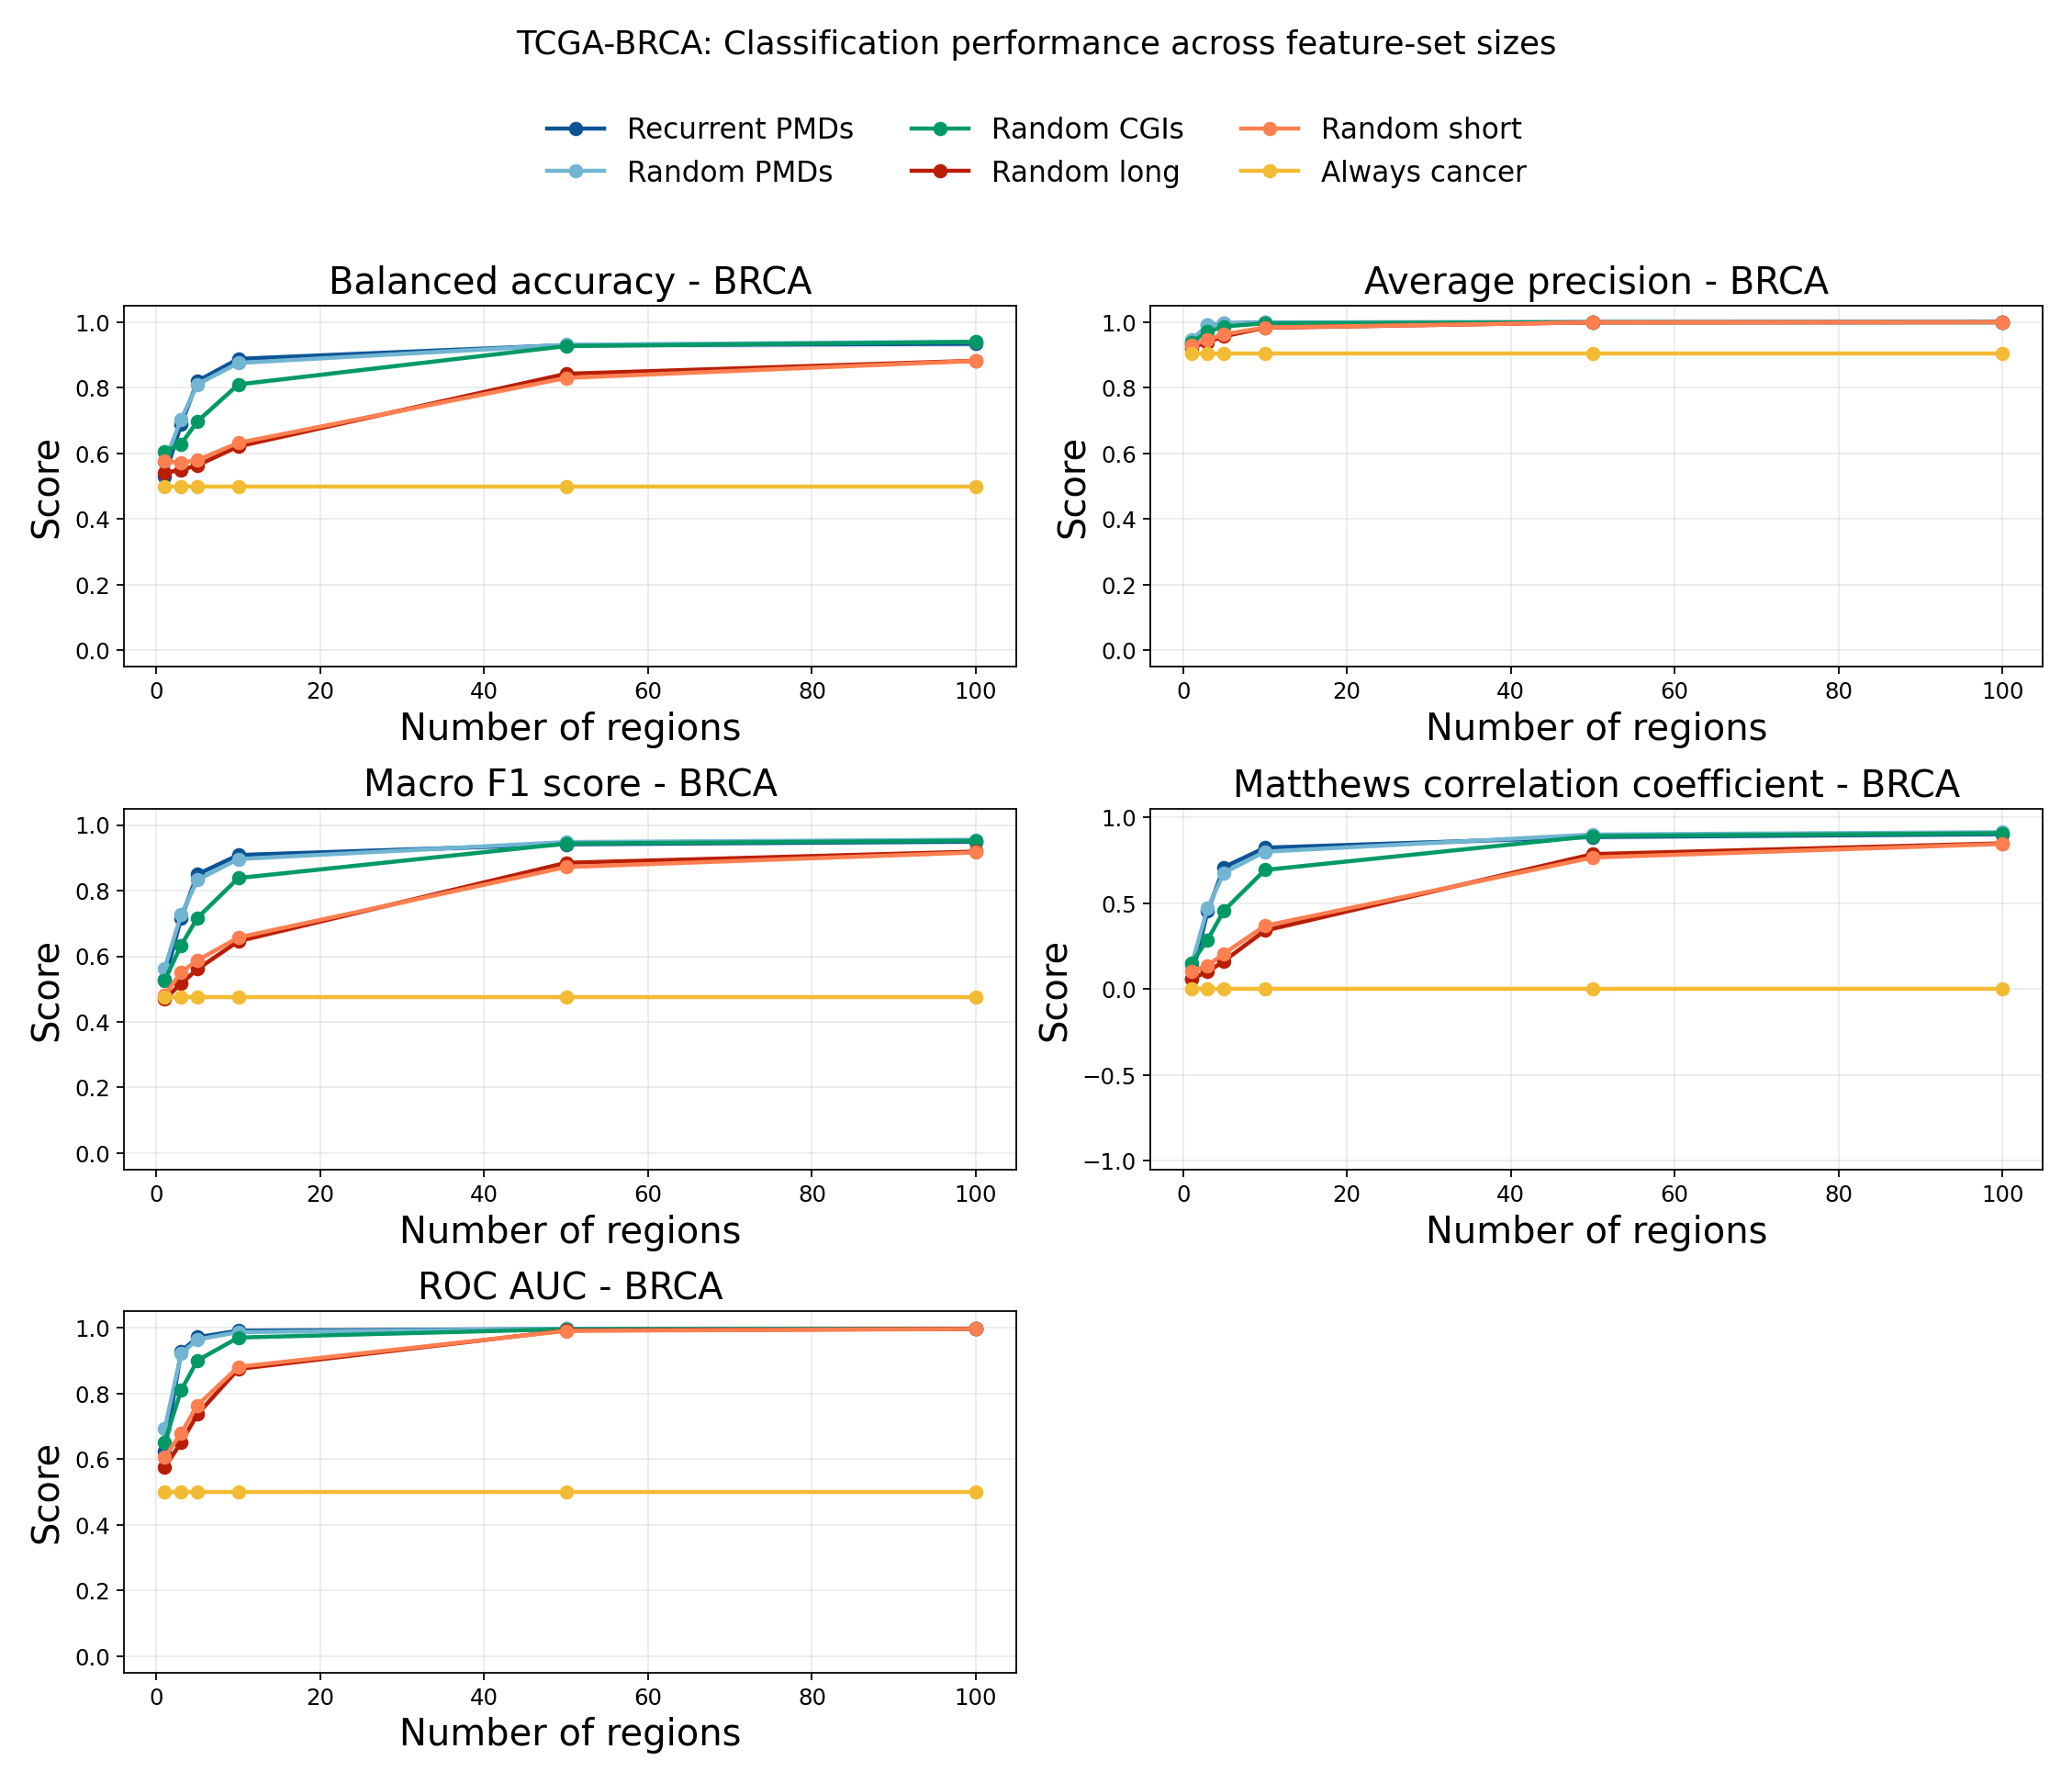

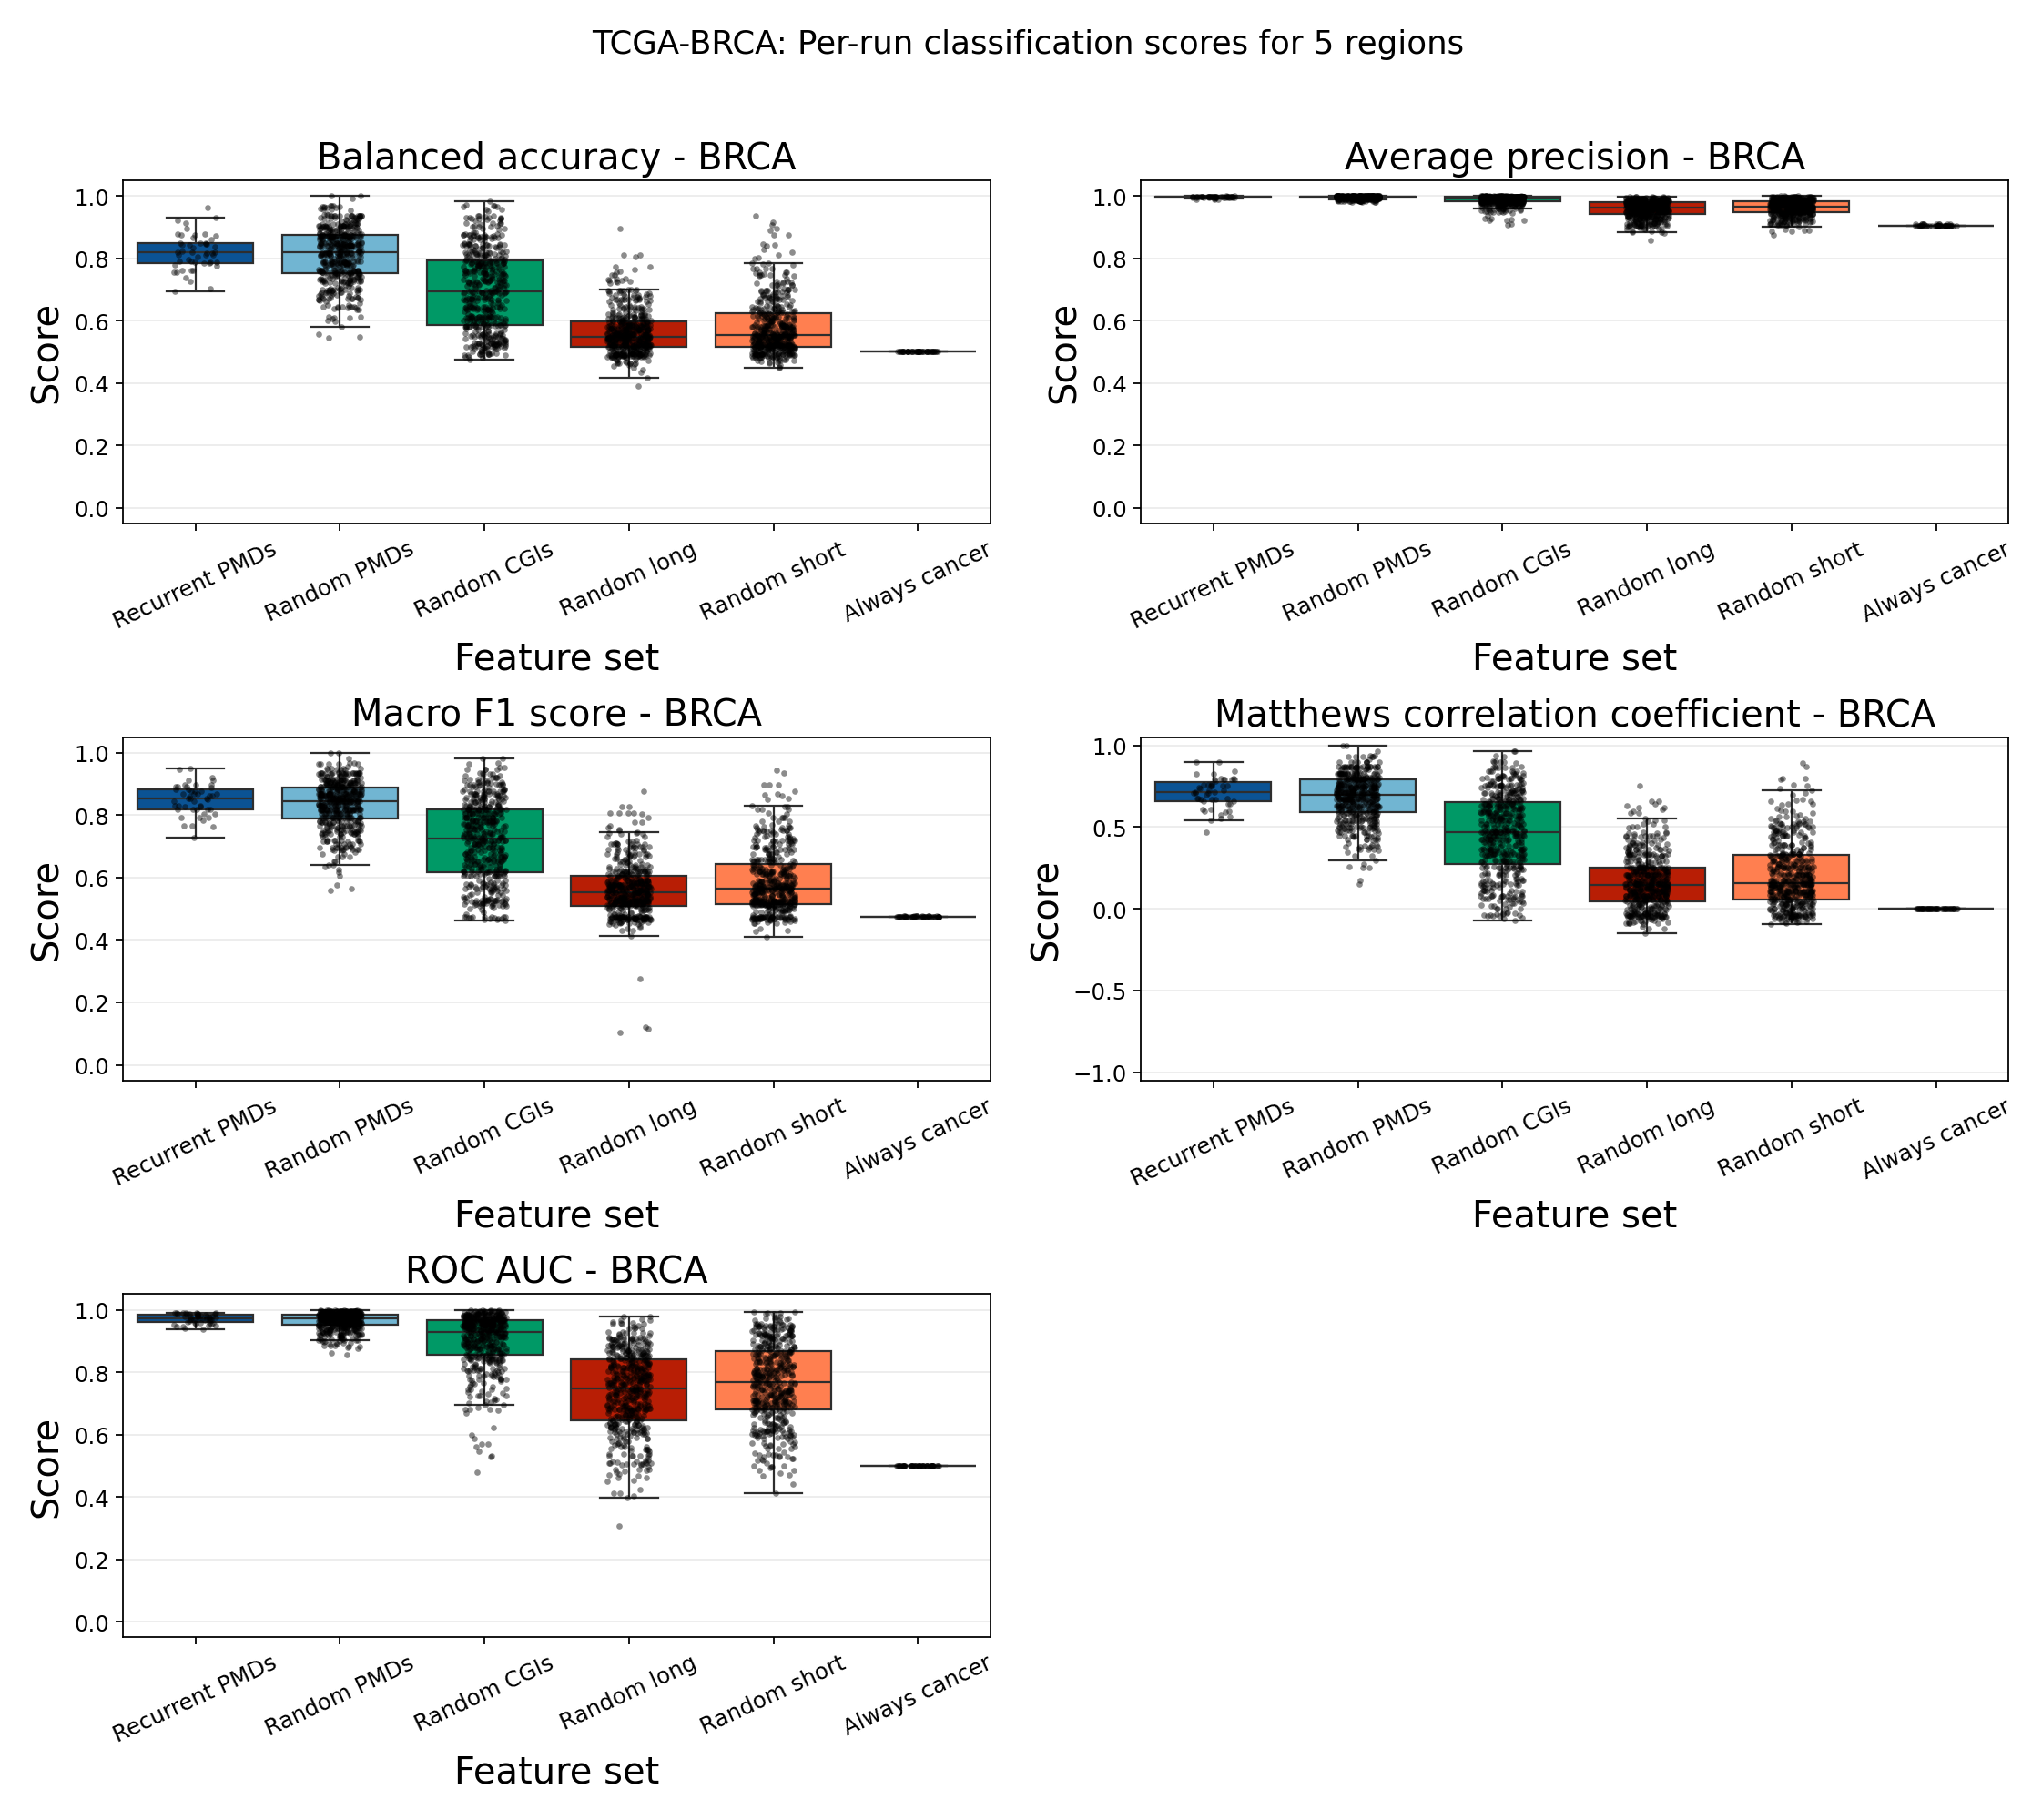

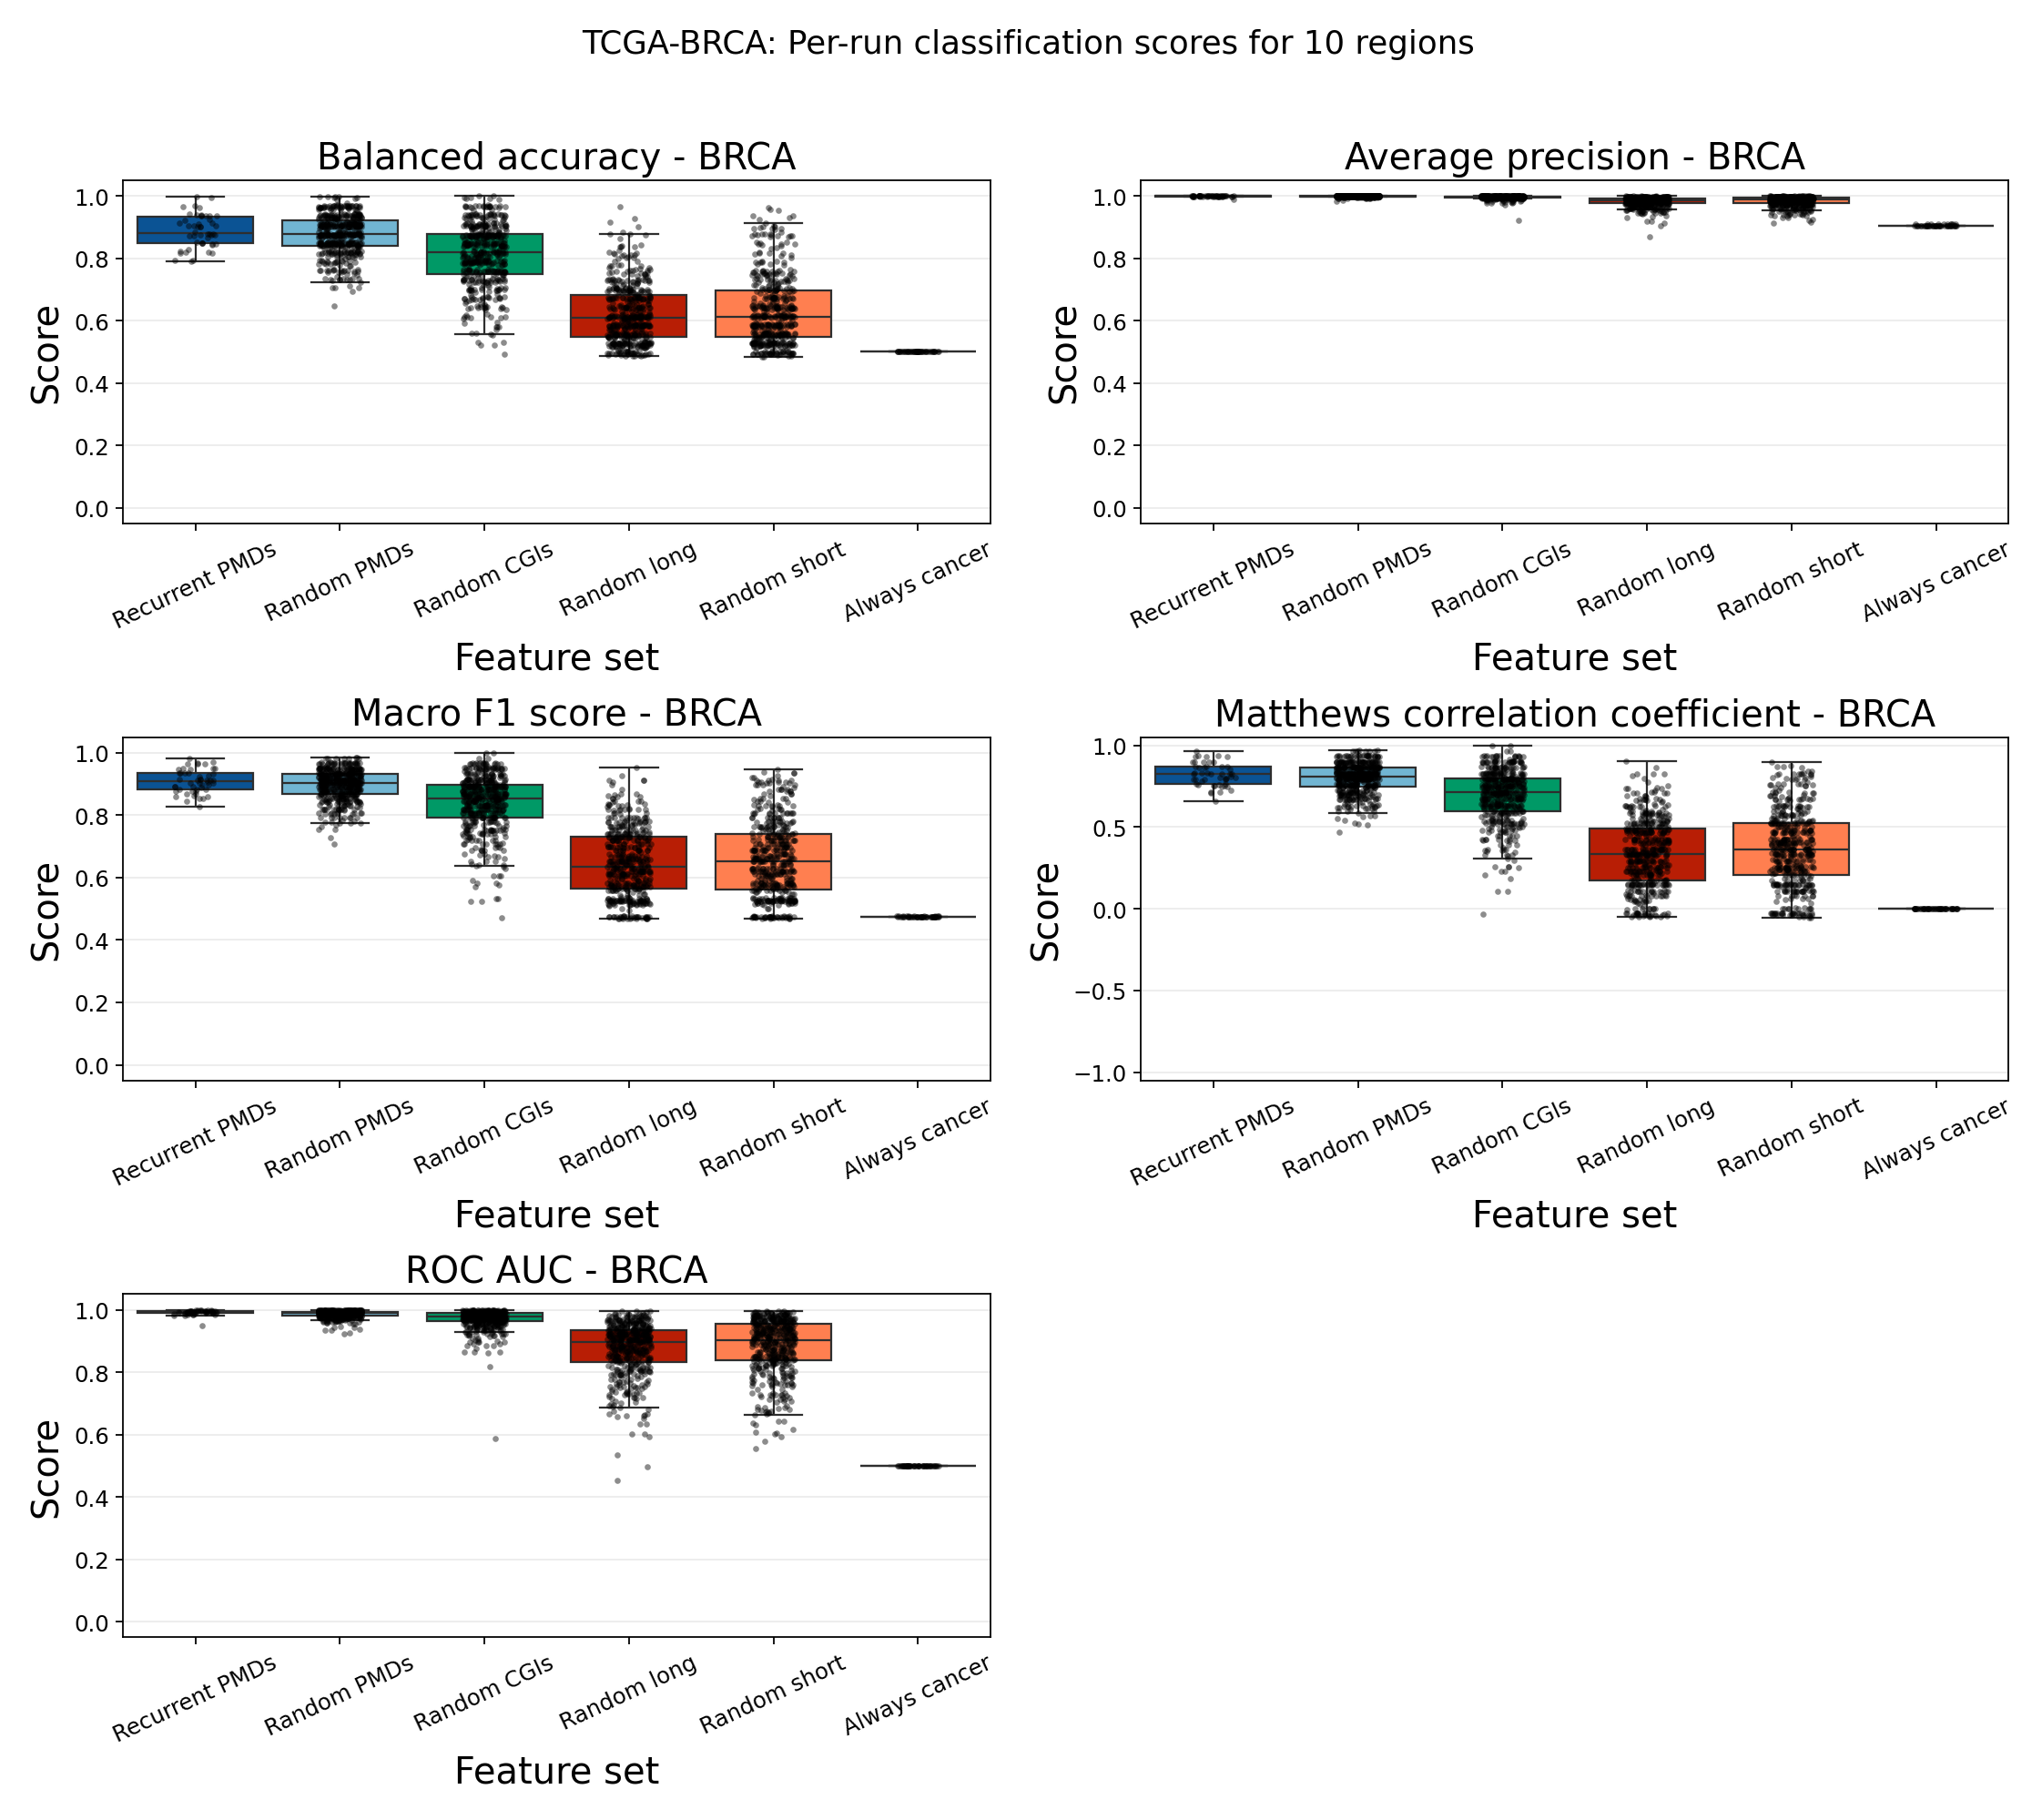

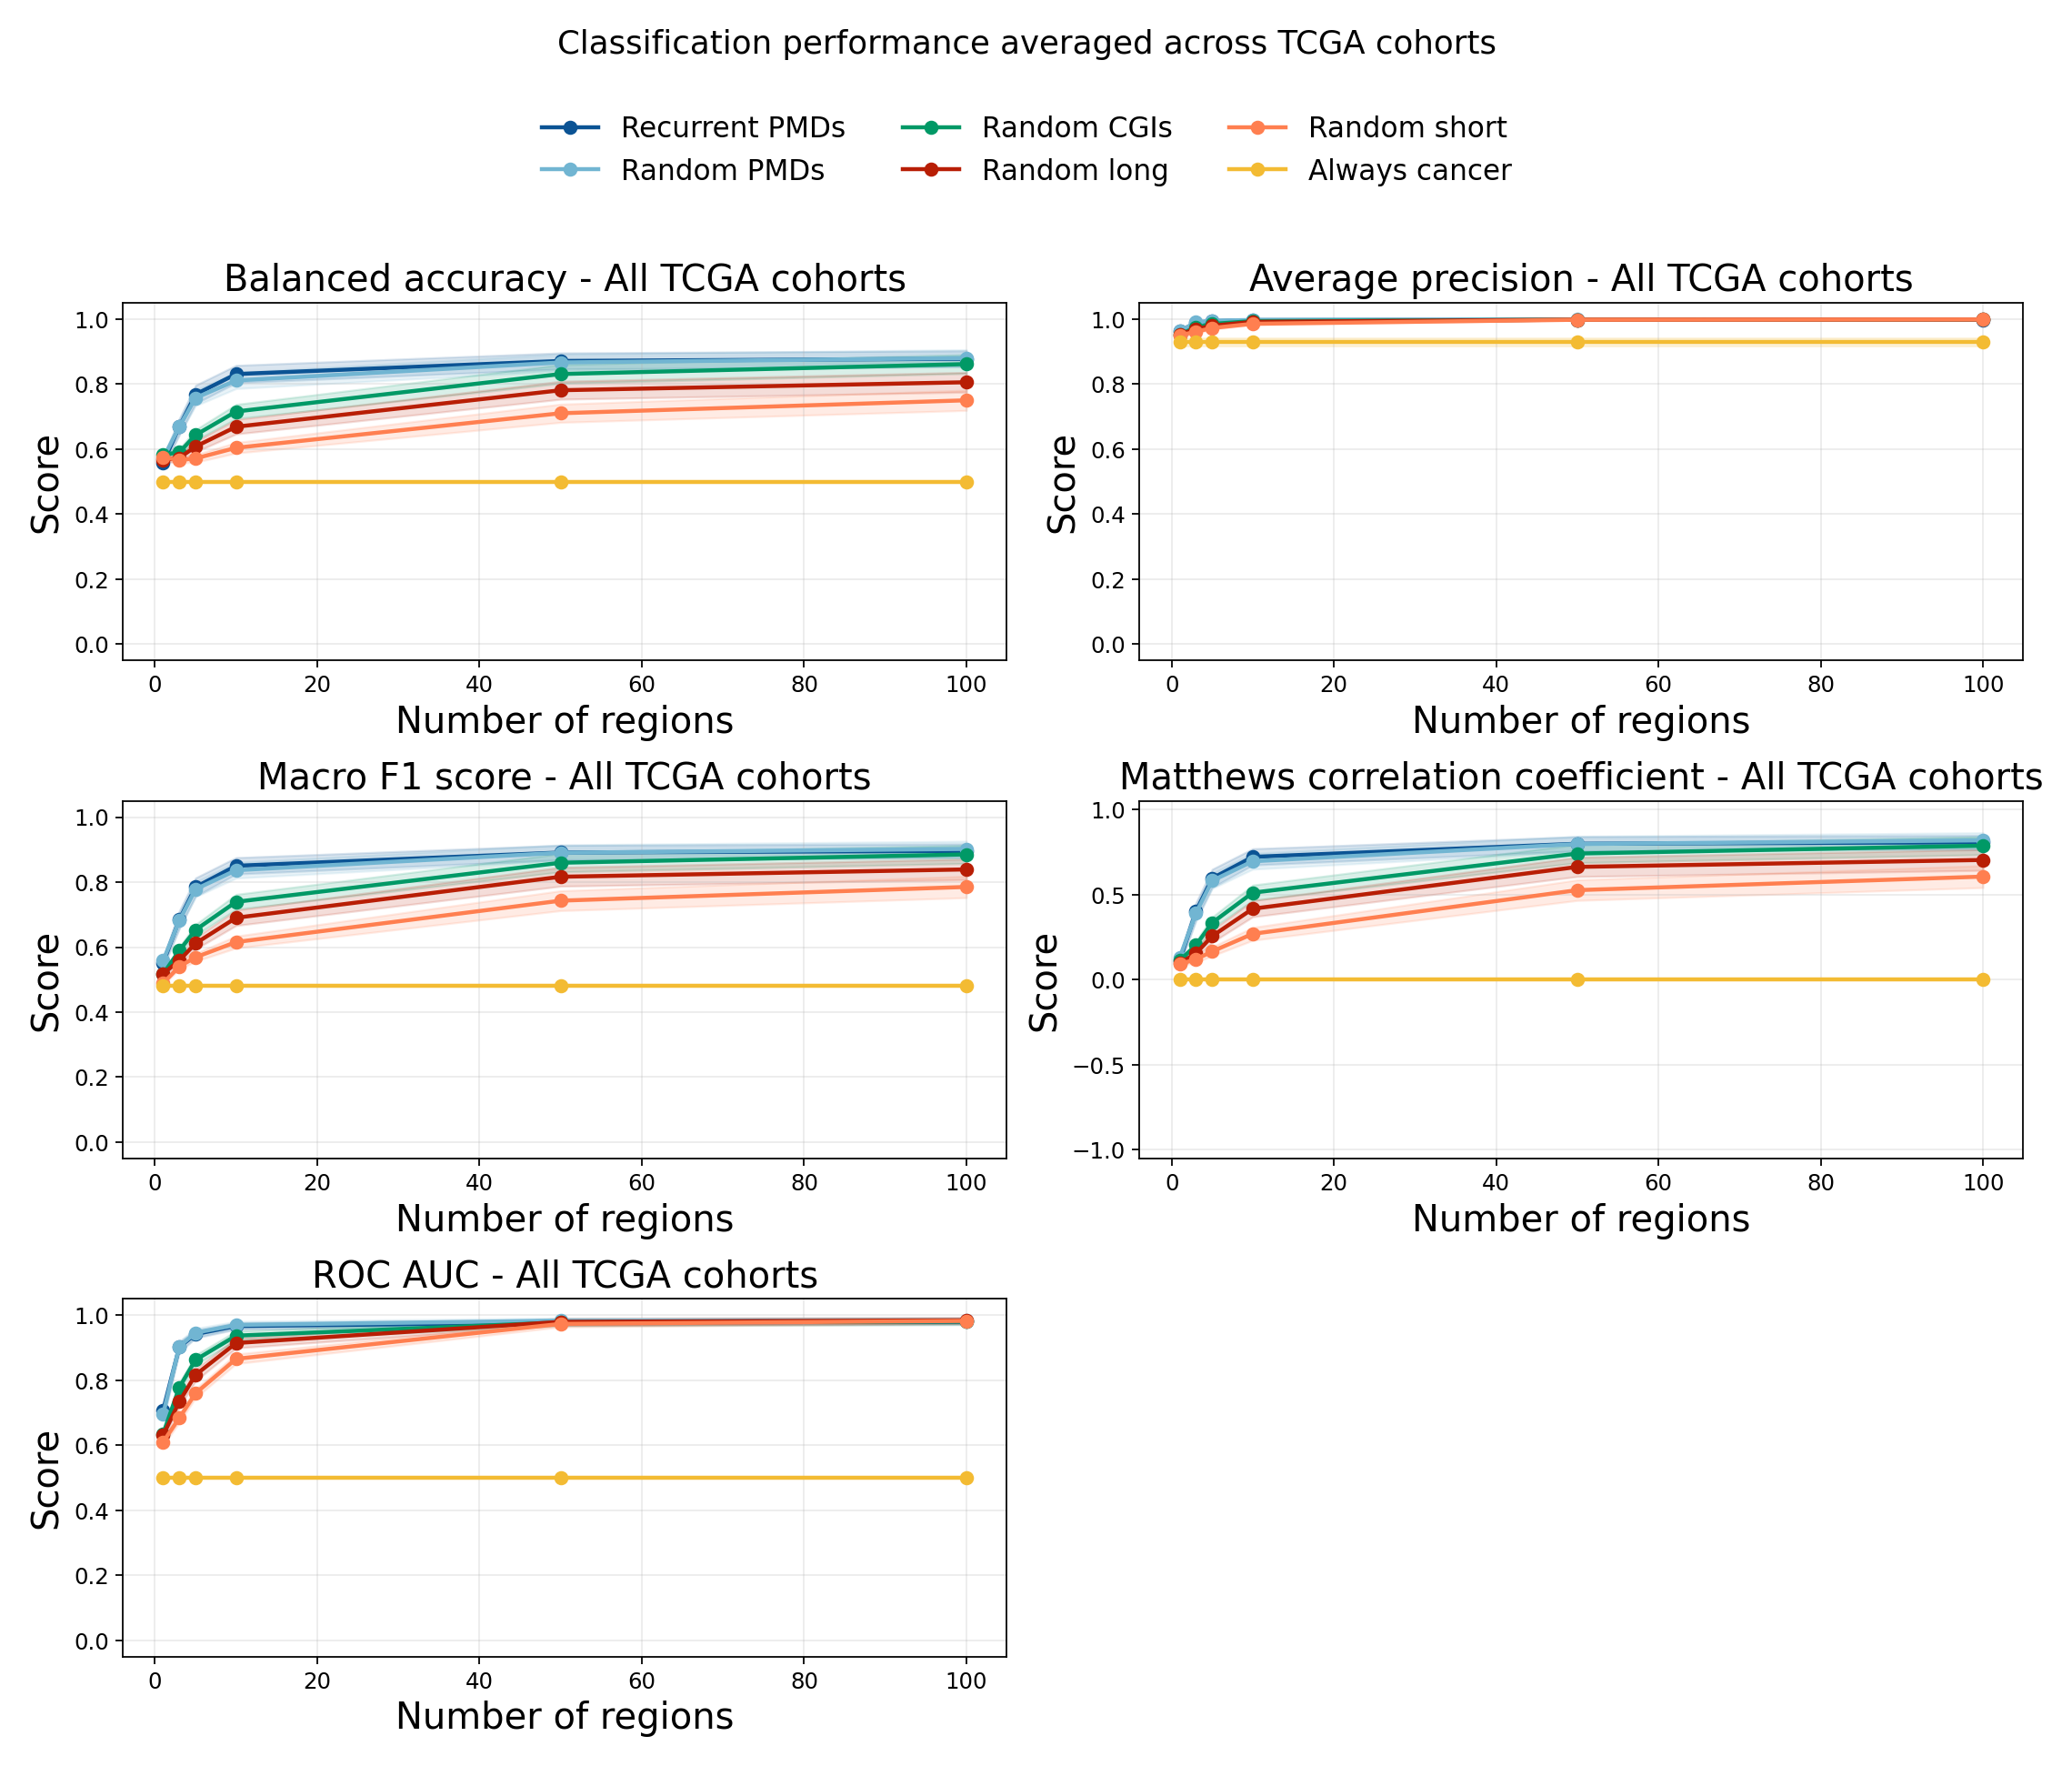

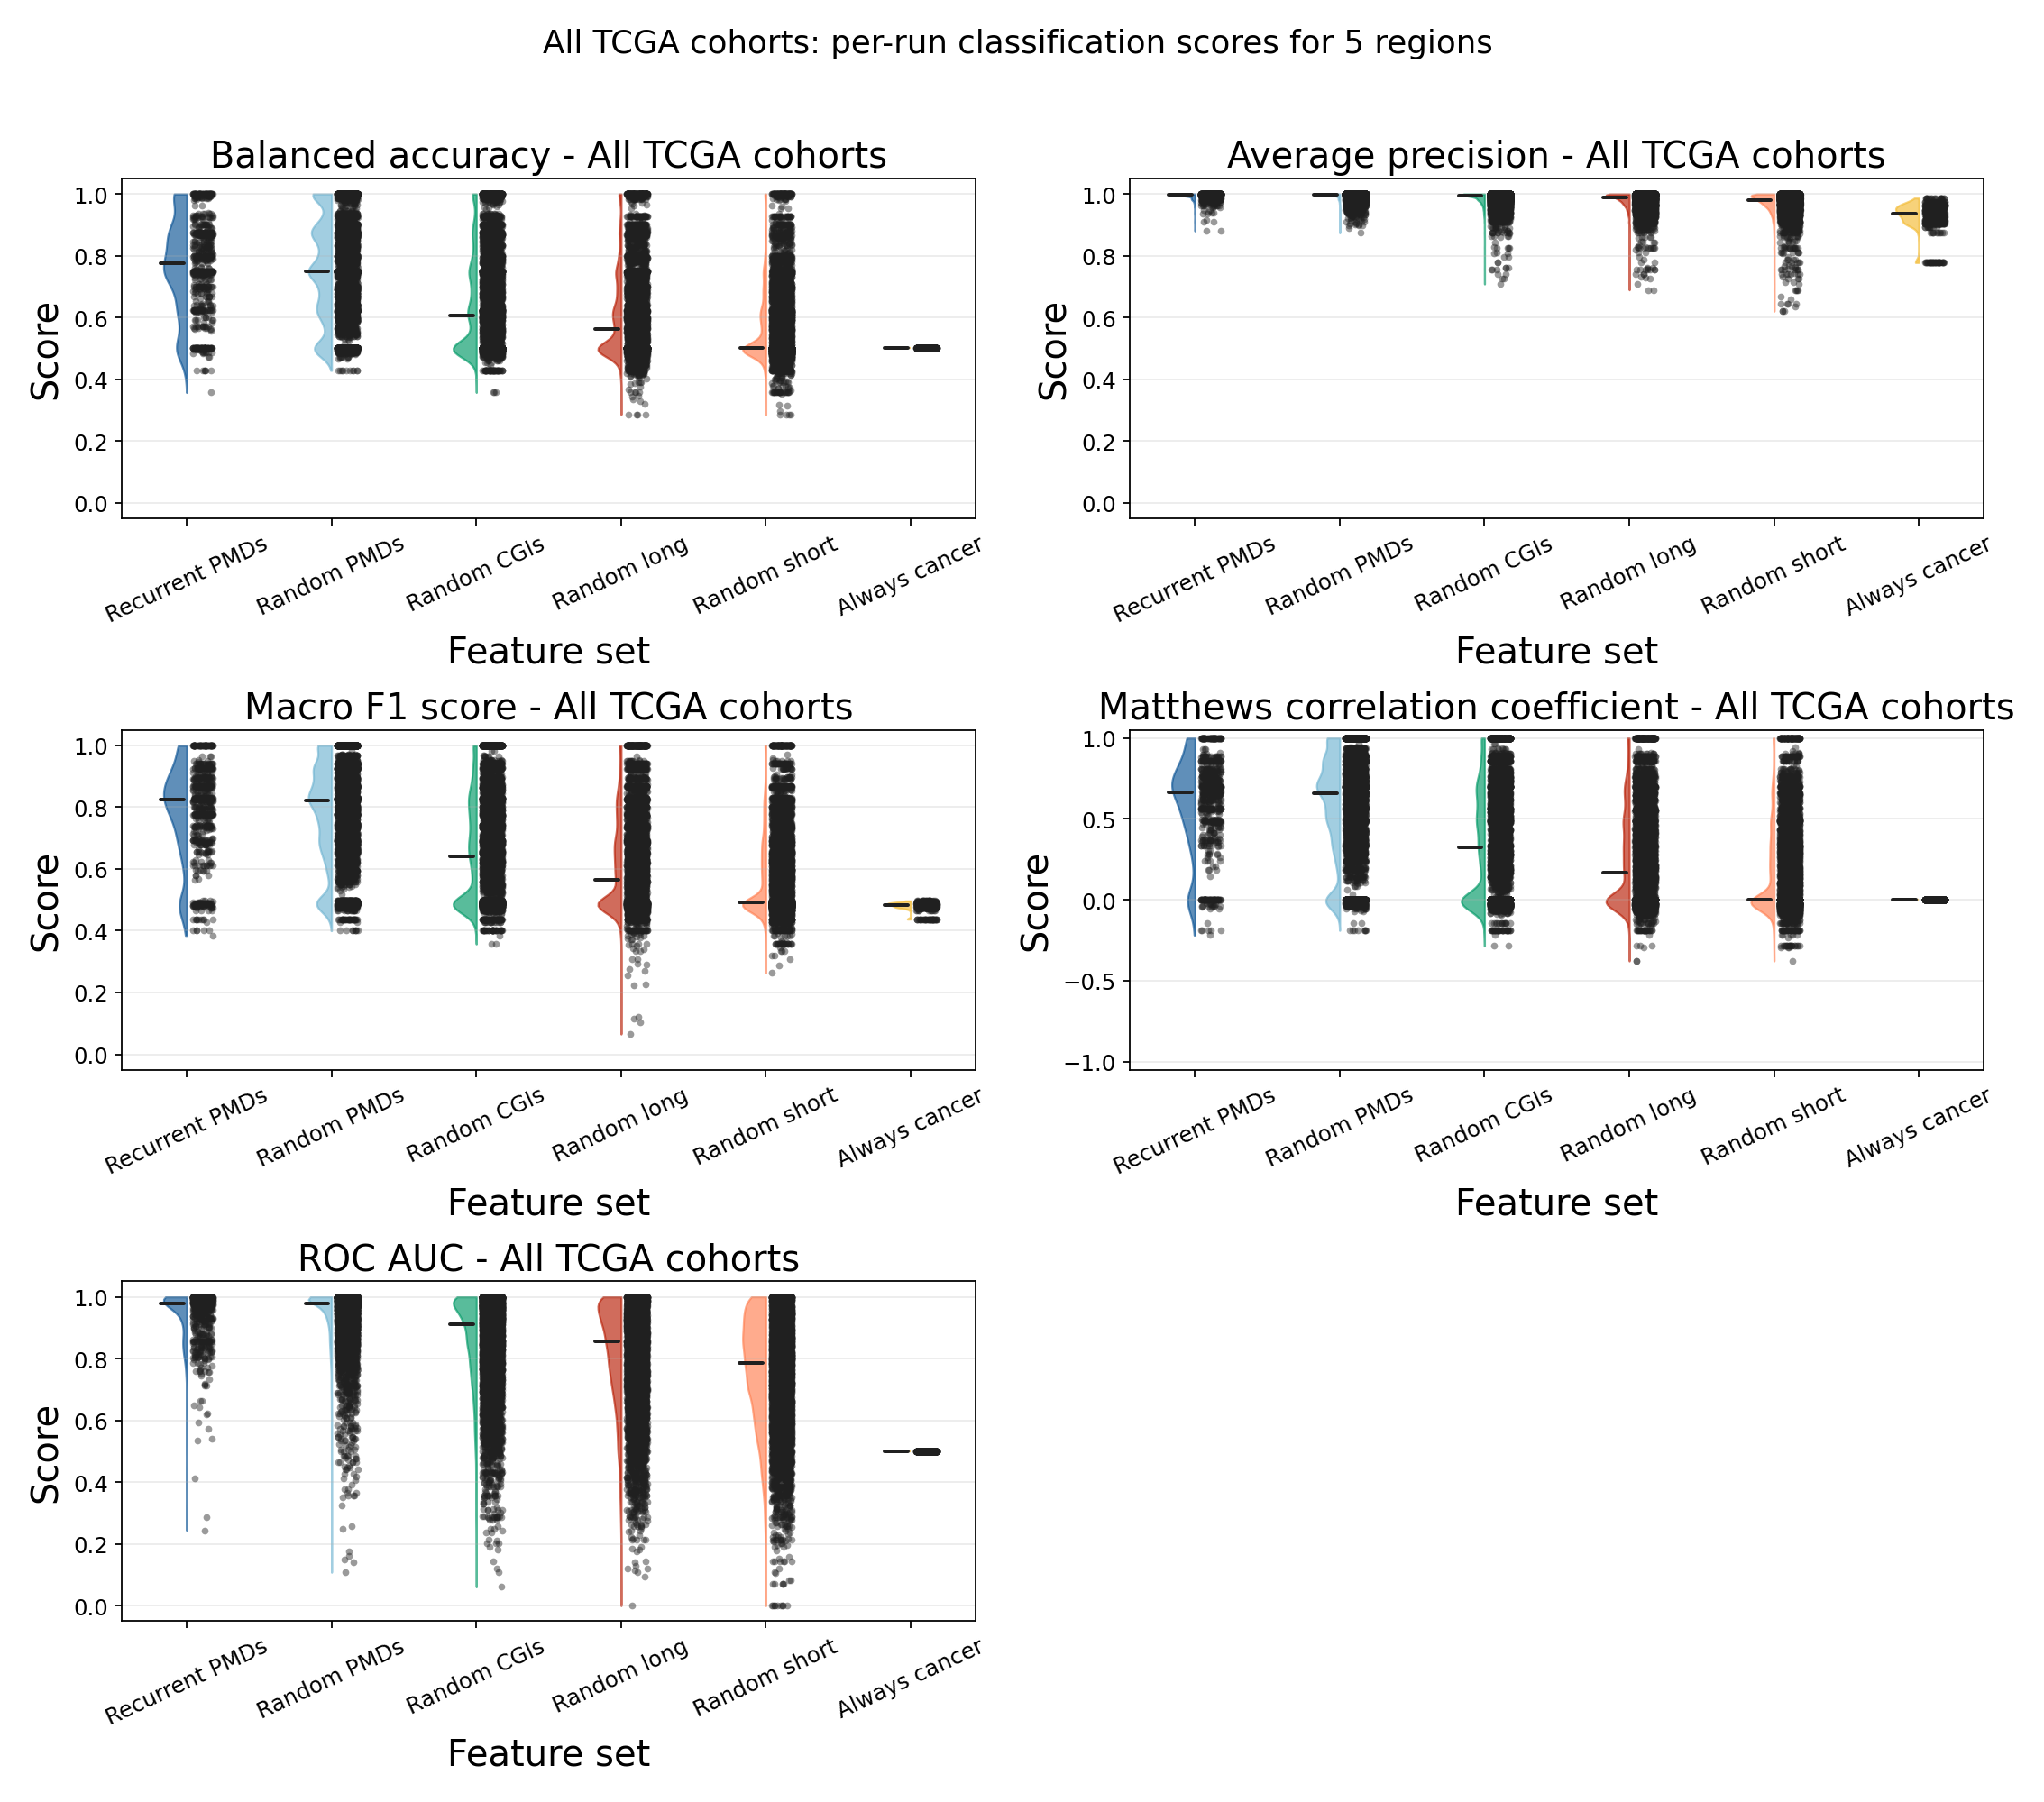

In [2]:
RESULTS_DIR = TCGA_CLASSIFICATION_RESULTS_DIR / "ml_outputs" / "per_cancer"
FIG_OUT_DIR = FIGURES_OUT_DIR / "06_tcga_figures"
FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)

DISPLAY_COHORT_ID = "TCGA-BRCA"
DISPLAY_LENGTH_PLOTS_IN_NOTEBOOK = False
PER_COHORT_BOXPLOT_SIZES = [5, 10]
AGGREGATE_LINE_FEATURE_SIZES = [1, 3, 5, 10, 50, 100]
AGGREGATE_BOXPLOT_N_FEATURES = 5
LENGTH_N_FEATURES = None
X_LOG_SCALE = False
METRICS = CLASSIFICATION_METRICS
BRCA_CONFUSION_N_FEATURES = 5
BRCA_CONFUSION_FEATURE_DRAW = 0
BRCA_CONFUSION_RANDOM_SEED = 42
BRCA_CONFUSION_SPLIT = None
BRCA_CONFUSION_REPEAT = None
BRCA_CONFUSION_FOLD = None
BRCA_CONFUSION_FOLD_KEY = None
BRCA_CONFUSION_SELECTION_INDEX = None
TCGA_HEATMAP_FILENAME_STEM = None
TCGA_HEATMAP_N_FEATURES = 5
TCGA_HEATMAP_METRIC = "macro_f1"
TCGA_HEATMAP_FEATURE_SET_ORDER = ["PMD", "Random PMD", "CGI", "Random long", "Random short", "Always cancer"]
TCGA_HEATMAP_EXPANDED_FEATURE_SETS = ["PMD", "Always cancer"]
TCGA_HEATMAP_EXTRA_WIDTH = 18
TCGA_HEATMAP_RIGHT_EDGE = 0.88
TCGA_HEATMAP_CBAR_X = 0.915
TCGA_HEATMAP_CBAR_WIDTH = 0.014
TCGA_HEATMAP_PREFER_HIGH_TO_LOW = True
TCGA_HEATMAP_PANEL_HEIGHT = 15.2
TCGA_HEATMAP_PANEL_HSPACE = 0.55
TCGA_HEATMAP_PANEL_SUBPLOT_GAP = 2.0
TCGA_HEATMAP_PANEL_TITLE_Y = 1.02
TCGA_F1_HEATMAP_BOUNDARIES = [0.0, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
TCGA_F1_HEATMAP_COLORBAR_TICKS = [0.0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
TCGA_F1_HEATMAP_COLORS = HEATMAP_COLOR_SCALES["tcga_macro_f1"]
TCGA_COHORT_AVG_HEATMAP_FILENAME_STEM = None
TCGA_COHORT_AVG_HEATMAP_N_FEATURES = TCGA_HEATMAP_N_FEATURES
TCGA_COHORT_AVG_HEATMAP_METRIC = "macro_f1"
TCGA_COHORT_AVG_HEATMAP_FEATURE_SET_ORDER = ["PMD", "Random PMD", "CGI", "Random long", "Random short", "Always cancer"]
TCGA_COHORT_AVG_HEATMAP_ANNOTATE = False
TCGA_PLOT_TITLE_SIZE = 18
TCGA_PLOT_LABEL_SIZE = 18
TCGA_PLOT_TICK_SIZE = 11
TCGA_FIGURE_TITLE_SIZE = 16
TCGA_LEGEND_FONT_SIZE = 14
TCGA_TABLE_FONT_SIZE = 11
TCGA_TABLE_TITLE_SIZE = 14
TCGA_PIE_LABEL_FONT_SIZE = 8
TCGA_PIE_TITLE_SIZE = 14

FEATURE_SET_PALETTE = FEATURE_SET_COLORS.copy()


def plot_classification_results_styled(*args, **kwargs):
    return plot_classification_results(
        *args,
        title_size=TCGA_PLOT_TITLE_SIZE,
        label_size=TCGA_PLOT_LABEL_SIZE,
        tick_size=TCGA_PLOT_TICK_SIZE,
        figure_title_size=TCGA_FIGURE_TITLE_SIZE,
        legend_font_size=TCGA_LEGEND_FONT_SIZE,
        **kwargs,
    )


def plot_classification_box_results_styled(*args, **kwargs):
    return plot_classification_box_results(
        *args,
        title_size=TCGA_PLOT_TITLE_SIZE,
        label_size=TCGA_PLOT_LABEL_SIZE,
        tick_size=TCGA_PLOT_TICK_SIZE,
        figure_title_size=TCGA_FIGURE_TITLE_SIZE,
        **kwargs,
    )


def plot_metric_summary_from_table_styled(*args, **kwargs):
    return plot_metric_summary_from_table(
        *args,
        title_size=TCGA_PLOT_TITLE_SIZE,
        label_size=TCGA_PLOT_LABEL_SIZE,
        tick_size=TCGA_PLOT_TICK_SIZE,
        figure_title_size=TCGA_FIGURE_TITLE_SIZE,
        legend_font_size=TCGA_LEGEND_FONT_SIZE,
        **kwargs,
    )


def plot_aggregate_box_data_styled(*args, **kwargs):
    return plot_aggregate_box_data(
        *args,
        title_size=TCGA_PLOT_TITLE_SIZE,
        label_size=TCGA_PLOT_LABEL_SIZE,
        tick_size=TCGA_PLOT_TICK_SIZE,
        figure_title_size=TCGA_FIGURE_TITLE_SIZE,
        **kwargs,
    )


def plot_summary_table_styled(*args, **kwargs):
    return plot_summary_table(
        *args,
        table_font_size=TCGA_TABLE_FONT_SIZE,
        title_size=TCGA_TABLE_TITLE_SIZE,
        **kwargs,
    )


def plot_used_sample_distribution_pies_styled(*args, **kwargs):
    return plot_used_sample_distribution_pies(
        *args,
        label_font_size=TCGA_PIE_LABEL_FONT_SIZE,
        axes_title_size=TCGA_PIE_TITLE_SIZE,
        figure_title_size=TCGA_FIGURE_TITLE_SIZE,
        **kwargs,
    )

cohort_ids = discover_saved_cohorts(RESULTS_DIR)
if not cohort_ids:
    raise FileNotFoundError(f"No saved cohort outputs were found under {RESULTS_DIR}.")

per_cohort_records = []
all_results = []
all_summaries = []
brca_fold_predictions = None
brca_confusion_note = None
brca_cohort_fig_dir = FIG_OUT_DIR / DISPLAY_COHORT_ID.lower()

for cohort_id in cohort_ids:
    display_this_cohort = cohort_id == DISPLAY_COHORT_ID
    fold_predictions = None
    if display_this_cohort:
        try:
            results, sampled_feature_regions, fold_predictions, task_summary = collect_saved_feature_classification_outputs(
                out_root=RESULTS_DIR,
                cohort_id=cohort_id,
                include_fold_predictions=True,
            )
        except FileNotFoundError as exc:
            if "fold predictions" not in str(exc):
                raise
            results, sampled_feature_regions, task_summary = collect_saved_feature_classification_outputs(
                out_root=RESULTS_DIR,
                cohort_id=cohort_id,
            )
            brca_confusion_note = (
                "BRCA confusion matrices were skipped because `fold_predictions.tsv` was not found. "
                "Rerun the BRCA classifier with the updated pipeline to generate that file."
            )
    else:
        results, sampled_feature_regions, task_summary = collect_saved_feature_classification_outputs(
            out_root=RESULTS_DIR,
            cohort_id=cohort_id,
        )

    results = results.copy()
    results["cohort_id"] = cohort_id
    all_results.append(results)

    cohort_summary, cohort_metric_fig = capture_plot(
        plot_classification_results_styled,
        results,
        metrics=METRICS,
        feature_set_order=FEATURE_SET_ORDER,
        palette=FEATURE_SET_PALETTE,
        feature_set_labels=FEATURE_SET_LABELS,
        x_log_scale=X_LOG_SCALE,
        subplot_title_suffix=format_cohort_label(cohort_id),
        figure_title=f"{cohort_id}: Classification performance across feature-set sizes",
    )
    cohort_summary = cohort_summary.copy()
    cohort_summary["cohort_id"] = cohort_id
    all_summaries.append(cohort_summary)

    cohort_slug = cohort_id.lower()
    cohort_fig_dir = FIG_OUT_DIR / cohort_slug
    cohort_fig_dir.mkdir(parents=True, exist_ok=True)

    metric_path = save_current_figure(cohort_fig_dir / f"{cohort_slug}__metric_lines.png", fig=cohort_metric_fig)
    record = {
        "cohort_id": cohort_id,
        "n_feature_sizes": int(task_summary["feature_count"].nunique()),
        "metric_lines": str(metric_path),
    }
    if display_this_cohort:
        display_saved_figure(metric_path)

    for boxplot_n_features in PER_COHORT_BOXPLOT_SIZES:
        _, boxplot_fig = capture_plot(
            plot_classification_box_results_styled,
            results,
            n_features=boxplot_n_features,
            metrics=METRICS,
            feature_set_order=FEATURE_SET_ORDER,
            palette=FEATURE_SET_PALETTE,
            feature_set_labels=FEATURE_SET_LABELS,
            subplot_title_suffix=format_cohort_label(cohort_id),
            figure_title=f"{cohort_id}: Per-run classification scores for {boxplot_n_features} regions",
        )
        box_path = save_current_figure(
            cohort_fig_dir / f"{cohort_slug}__n{boxplot_n_features:04d}__boxplots.png",
            fig=boxplot_fig,
        )
        record[f"boxplots_n{boxplot_n_features}"] = str(box_path)
        if display_this_cohort:
            display_saved_figure(box_path)

    classification_length_data, length_fig = capture_plot(
        plot_sampled_feature_length_distributions,
        sampled_feature_regions,
        n_features=LENGTH_N_FEATURES,
        feature_set_order=[feature for feature in FEATURE_SET_ORDER if feature != "Always cancer"],
        palette={key: value for key, value in FEATURE_SET_PALETTE.items() if key != "Always cancer"},
    )
    relabel_current_figure(
        (
            f"{cohort_id}: Sampled region lengths across all feature-set sizes"
            if LENGTH_N_FEATURES is None
            else f"{cohort_id}: Sampled region lengths for {LENGTH_N_FEATURES} features"
        ),
        y=0.98,
        rect=[0, 0, 1, 0.96],
        fontsize=TCGA_FIGURE_TITLE_SIZE,
        fig=length_fig,
    )
    length_name = (
        f"{cohort_slug}__all_sizes__length_histograms.png"
        if LENGTH_N_FEATURES is None
        else f"{cohort_slug}__n{LENGTH_N_FEATURES:04d}__length_histograms.png"
    )
    length_path = save_current_figure(cohort_fig_dir / length_name, fig=length_fig)
    record["length_histograms"] = str(length_path)
    if display_this_cohort and DISPLAY_LENGTH_PLOTS_IN_NOTEBOOK:
        display_saved_figure(length_path)

    density_fig, density_ax = plt.subplots(figsize=(10, 6))
    for display_feature_set, feature_df in classification_length_data.groupby("display_feature_set", sort=False):
        lengths = feature_df["length"].dropna().astype(float)
        if lengths.empty:
            continue
        raw_feature_set = str(feature_df["feature_set"].dropna().astype(str).iloc[0])
        color = FEATURE_SET_PALETTE.get(raw_feature_set)
        if lengths.nunique() > 1 and len(lengths) > 1:
            sns.kdeplot(
                x=lengths,
                ax=density_ax,
                log_scale=True,
                common_norm=False,
                bw_adjust=0.9,
                fill=False,
                linewidth=2,
                color=color,
                label=str(display_feature_set),
            )
        else:
            density_ax.axvline(
                lengths.iloc[0],
                color=color,
                linewidth=2,
                linestyle="--",
                label=str(display_feature_set),
            )
    density_ax.set_xscale("log")
    density_ax.set_title(
        (
            f"{cohort_id}: Sampled region length density across all feature-set sizes"
            if LENGTH_N_FEATURES is None
            else f"{cohort_id}: Sampled region length density for {LENGTH_N_FEATURES} features"
        ),
        fontsize=TCGA_PLOT_TITLE_SIZE,
    )
    density_ax.set_xlabel("Region length (bp, log scale)", fontsize=TCGA_PLOT_LABEL_SIZE)
    density_ax.set_ylabel("Density", fontsize=TCGA_PLOT_LABEL_SIZE)
    density_ax.tick_params(axis="both", labelsize=TCGA_PLOT_TICK_SIZE)
    density_ax.grid(True, axis="y", alpha=0.25)
    density_ax.legend(frameon=False, fontsize=TCGA_LEGEND_FONT_SIZE)
    density_name = (
        f"{cohort_slug}__all_sizes__length_density.png"
        if LENGTH_N_FEATURES is None
        else f"{cohort_slug}__n{LENGTH_N_FEATURES:04d}__length_density.png"
    )
    density_path = save_current_figure(cohort_fig_dir / density_name, fig=density_fig)
    record["length_density"] = str(density_path)
    if display_this_cohort and DISPLAY_LENGTH_PLOTS_IN_NOTEBOOK:
        display_saved_figure(density_path)

    if display_this_cohort and fold_predictions is not None:
        brca_fold_predictions = fold_predictions.copy()

    per_cohort_records.append(record)

all_results_df = pd.concat(all_results, ignore_index=True)
all_summaries_df = pd.concat(all_summaries, ignore_index=True)

aggregate_line_summary = summarize_across_cohorts(
    all_summaries_df,
    feature_sizes=AGGREGATE_LINE_FEATURE_SIZES,
)
_, aggregate_line_fig = capture_plot(
    plot_metric_summary_from_table_styled,
    aggregate_line_summary,
    metrics=METRICS,
    feature_set_order=FEATURE_SET_ORDER,
    palette=FEATURE_SET_PALETTE,
    feature_set_labels=FEATURE_SET_LABELS,
    x_log_scale=X_LOG_SCALE,
    title="Classification performance averaged across TCGA cohorts",
    subplot_title_suffix="All TCGA cohorts",
)
aggregate_line_path = save_current_figure(FIG_OUT_DIR / "all_cohorts__metric_lines.png", fig=aggregate_line_fig)
display_saved_figure(aggregate_line_path)

aggregate_box_data = build_aggregate_box_data(
    all_results_df,
    n_features=AGGREGATE_BOXPLOT_N_FEATURES,
    metrics=METRICS,
    feature_set_order=FEATURE_SET_ORDER,
    feature_set_labels=FEATURE_SET_LABELS,
)
_, aggregate_box_fig = capture_plot(
    plot_aggregate_box_data_styled,
    aggregate_box_data,
    metrics=METRICS,
    feature_set_order=FEATURE_SET_ORDER,
    palette=FEATURE_SET_PALETTE,
    feature_set_labels=FEATURE_SET_LABELS,
    n_features=AGGREGATE_BOXPLOT_N_FEATURES,
    subplot_title_suffix="All TCGA cohorts",
)
aggregate_box_path = save_current_figure(
    FIG_OUT_DIR / f"all_cohorts__n{AGGREGATE_BOXPLOT_N_FEATURES:04d}__boxplots.png",
    fig=aggregate_box_fig,
)
display_saved_figure(aggregate_box_path)

brca_confusion_path = None
brca_confusion_output_summary = None
available_brca_confusion_splits = None

per_cohort_output_summary = pd.DataFrame(per_cohort_records).sort_values("cohort_id").reset_index(drop=True)
aggregate_output_summary = pd.Series(
    {
        "n_cohorts": int(len(cohort_ids)),
        "aggregate_line_feature_sizes": ", ".join(str(size) for size in AGGREGATE_LINE_FEATURE_SIZES),
        "aggregate_line_plot": str(aggregate_line_path),
        "aggregate_boxplot_n_features": int(AGGREGATE_BOXPLOT_N_FEATURES),
        "aggregate_boxplot": str(aggregate_box_path),
    }
)
brca_output_summary = per_cohort_output_summary.loc[
    per_cohort_output_summary["cohort_id"] == DISPLAY_COHORT_ID
].reset_index(drop=True)


,selection_index,fold_key,split,repeat,fold,feature_set,n_available_feature_sets,missing_feature_sets,has_all_feature_sets
0,0,repeat_00_fold_00_split_0000,0,0,0,"[Always cancer, CGI, PMD, Random PMD, Random l...",6,[],True
1,1,repeat_00_fold_01_split_0001,1,0,1,"[Always cancer, CGI, PMD, Random PMD, Random l...",6,[],True
2,2,repeat_00_fold_02_split_0002,2,0,2,"[Always cancer, CGI, PMD, Random PMD, Random l...",6,[],True
3,3,repeat_00_fold_03_split_0003,3,0,3,"[Always cancer, CGI, PMD, Random PMD, Random l...",6,[],True
4,4,repeat_00_fold_04_split_0004,4,0,4,"[Always cancer, CGI, PMD, Random PMD, Random l...",6,[],True
5,5,repeat_01_fold_00_split_0005,5,1,0,"[Always cancer, CGI, PMD, Random PMD, Random l...",6,[],True
6,6,repeat_01_fold_01_split_0006,6,1,1,"[Always cancer, CGI, PMD, Random PMD, Random l...",6,[],True
7,7,repeat_01_fold_02_split_0007,7,1,2,"[Always cancer, CGI, PMD, Random PMD, Random l...",6,[],True
8,8,repeat_01_fold_03_split_0008,8,1,3,"[Always cancer, CGI, PMD, Random PMD, Random l...",6,[],True
9,9,repeat_01_fold_04_split_0009,9,1,4,"[Always cancer, CGI, PMD, Random PMD, Random l...",6,[],True


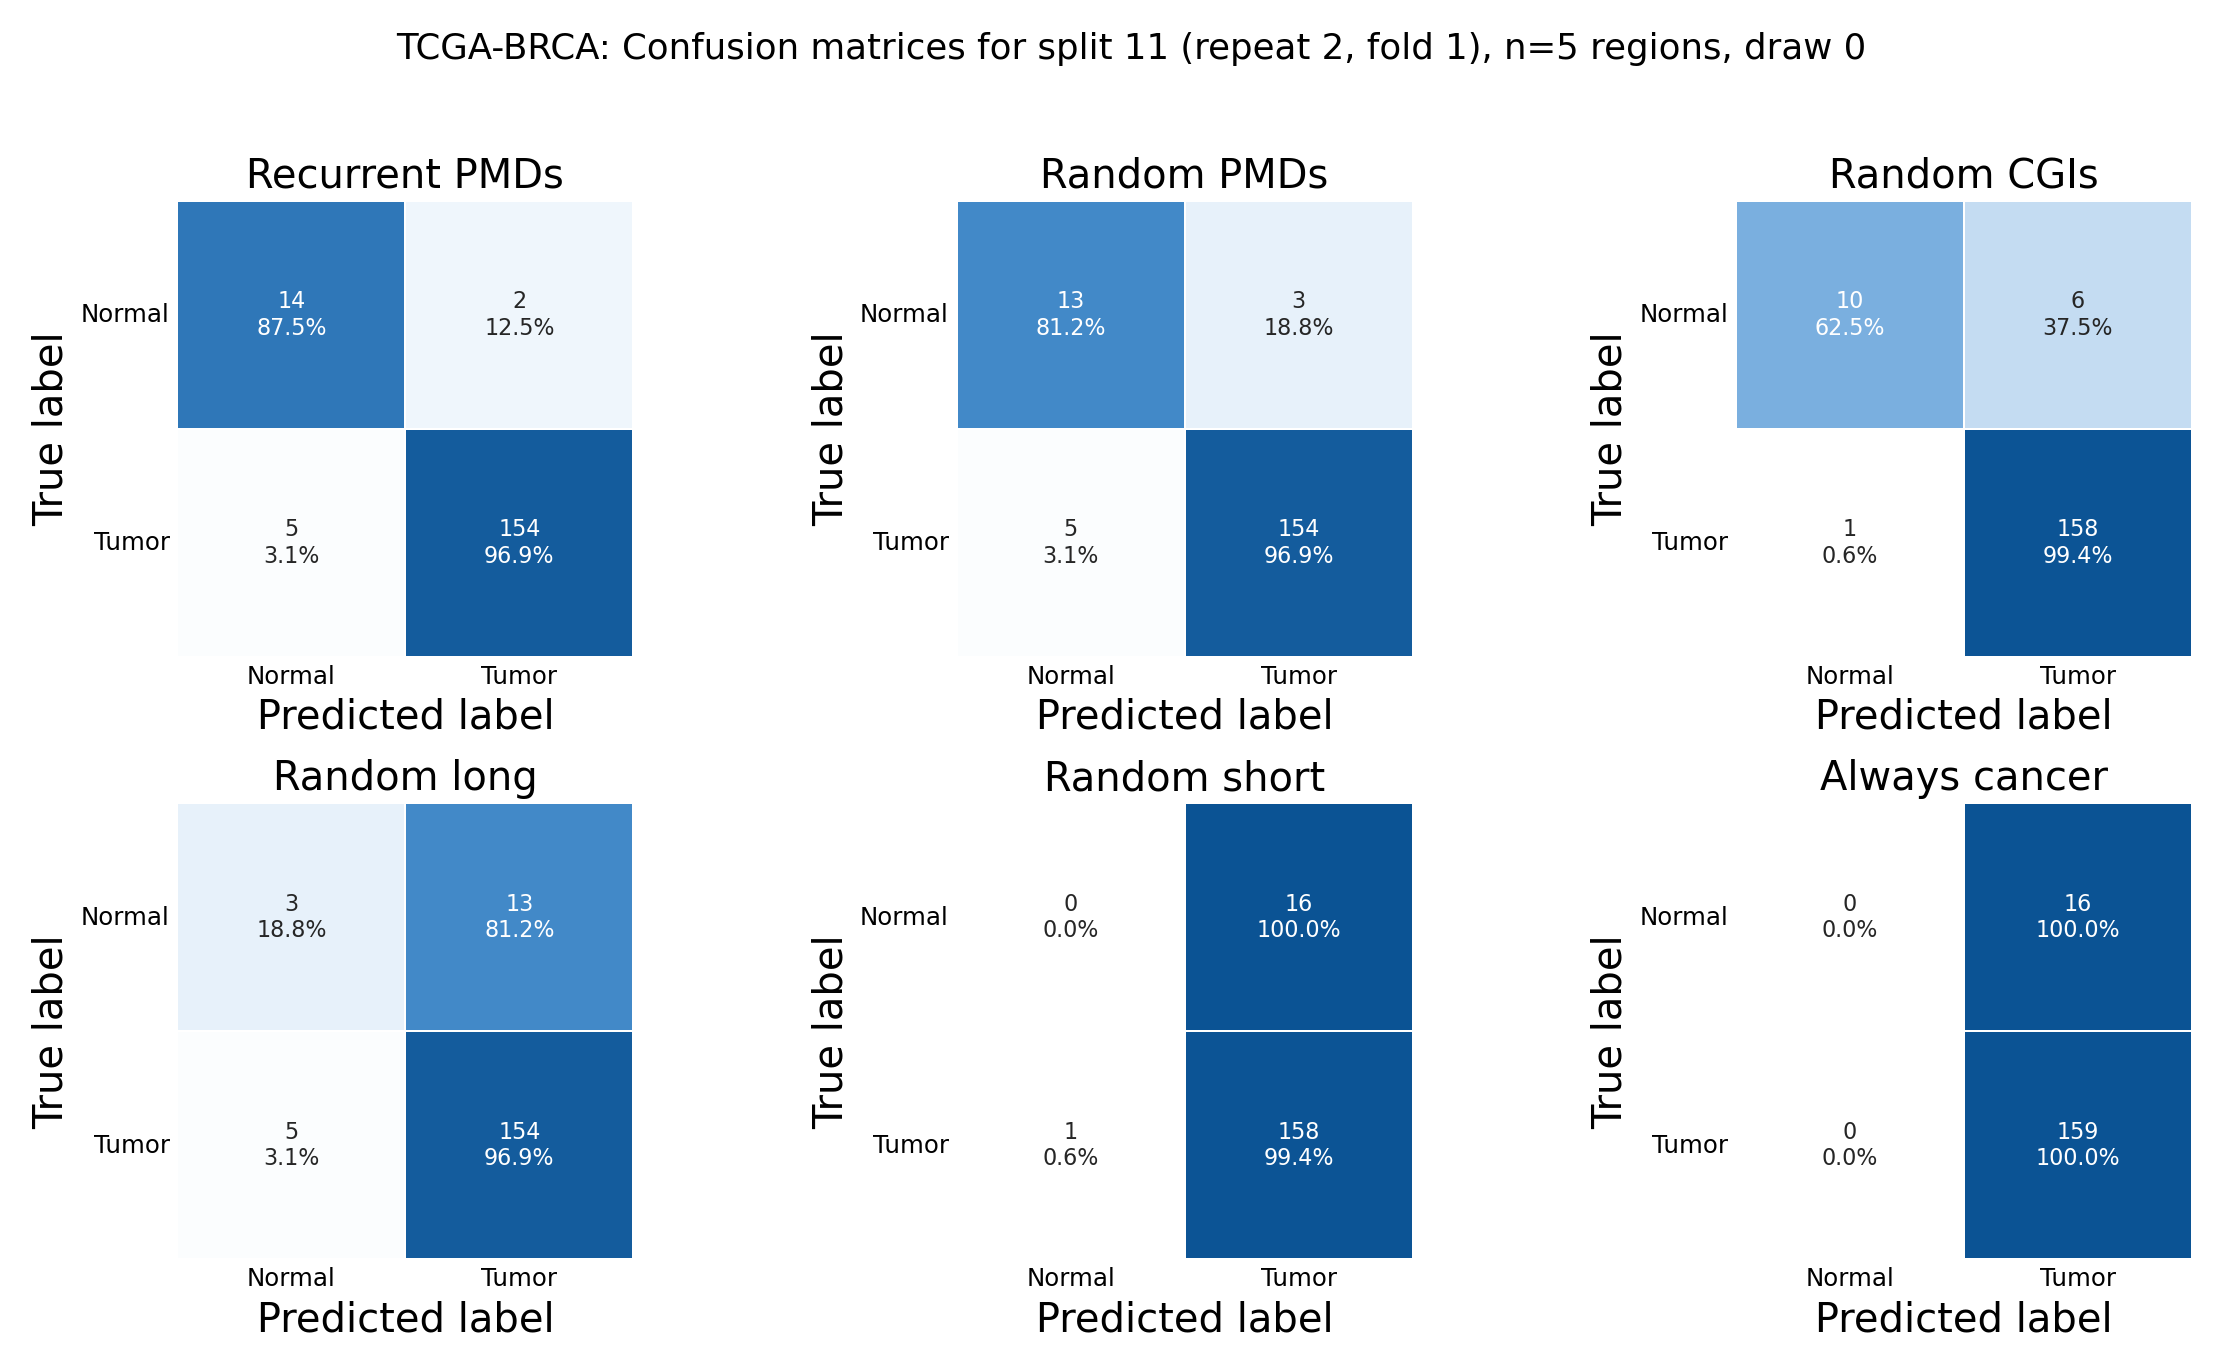

cohort_id                                                  TCGA-BRCA
selection_index                                                   11
fold_key                                repeat_02_fold_01_split_0011
split                                                             11
repeat                                                             2
fold                                                               1
n_features                                                         5
feature_draw                                                       0
figure_path        /uufs/chpc.utah.edu/common/home/clementm-group...
dtype: object

In [3]:
# BRCA confusion matrices
#
# Rerun this cell after changing the BRCA_CONFUSION_* values above.
# To target a specific fold, set BRCA_CONFUSION_SPLIT / BRCA_CONFUSION_REPEAT /
# BRCA_CONFUSION_FOLD, BRCA_CONFUSION_FOLD_KEY, or BRCA_CONFUSION_SELECTION_INDEX.

brca_confusion_output_summary = None
available_brca_confusion_splits = None

if brca_confusion_note:
    display_note(brca_confusion_note)
elif brca_fold_predictions is None or brca_fold_predictions.empty:
    display_note("BRCA confusion matrices are not available in the current cache.")
else:
    available_brca_confusion_splits = list_available_fold_choices(
        brca_fold_predictions,
        n_features=BRCA_CONFUSION_N_FEATURES,
        feature_draw=BRCA_CONFUSION_FEATURE_DRAW,
        required_feature_sets=FEATURE_SET_ORDER,
        only_complete=True,
    )
    display(available_brca_confusion_splits)
    brca_selected_fold_predictions, brca_confusion_selection = select_fold_predictions(
        brca_fold_predictions,
        n_features=5,
        feature_draw=0,
        #fold_key=BRCA_CONFUSION_FOLD_KEY,
        split=11,
        repeat=2,
        fold=1,
        #selection_index=BRCA_CONFUSION_SELECTION_INDEX,
        #random_seed=BRCA_CONFUSION_RANDOM_SEED,
        required_feature_sets=FEATURE_SET_ORDER,
        prefer_complete=True,
    )
    brca_confusion_fig, _ = plot_confusion_matrix_grid(
        brca_selected_fold_predictions,
        feature_set_order=FEATURE_SET_ORDER,
        feature_set_labels=FEATURE_SET_LABELS,
        figure_title=(
            f"{DISPLAY_COHORT_ID}: Confusion matrices for split {brca_confusion_selection['split']} "
            f"(repeat {brca_confusion_selection['repeat']}, fold {brca_confusion_selection['fold']}), "
            f"n={brca_confusion_selection['n_features']} regions, draw {brca_confusion_selection['feature_draw']}"
        ),
        title_size=TCGA_PLOT_TITLE_SIZE,
        label_size=TCGA_PLOT_LABEL_SIZE,
        tick_size=TCGA_PLOT_TICK_SIZE,
        figure_title_size=TCGA_FIGURE_TITLE_SIZE,
    )
    brca_confusion_path = save_current_figure(
        brca_cohort_fig_dir / (
            f"{DISPLAY_COHORT_ID.lower()}__n{BRCA_CONFUSION_N_FEATURES:04d}__draw{BRCA_CONFUSION_FEATURE_DRAW:04d}__split{brca_confusion_selection['split']:04d}__confusion_matrices.png"
        ),
        fig=brca_confusion_fig,
    )
    display_saved_figure(brca_confusion_path)
    brca_confusion_output_summary = pd.Series(
        {
            "cohort_id": DISPLAY_COHORT_ID,
            "selection_index": int(brca_confusion_selection["selection_index"]),
            "fold_key": brca_confusion_selection["fold_key"],
            "split": int(brca_confusion_selection["split"]),
            "repeat": int(brca_confusion_selection["repeat"]),
            "fold": int(brca_confusion_selection["fold"]),
            "n_features": int(brca_confusion_selection["n_features"]),
            "feature_draw": int(brca_confusion_selection["feature_draw"]),
            "figure_path": str(brca_confusion_path),
        }
    )

brca_confusion_output_summary


Plotting HeatmapAnnotations


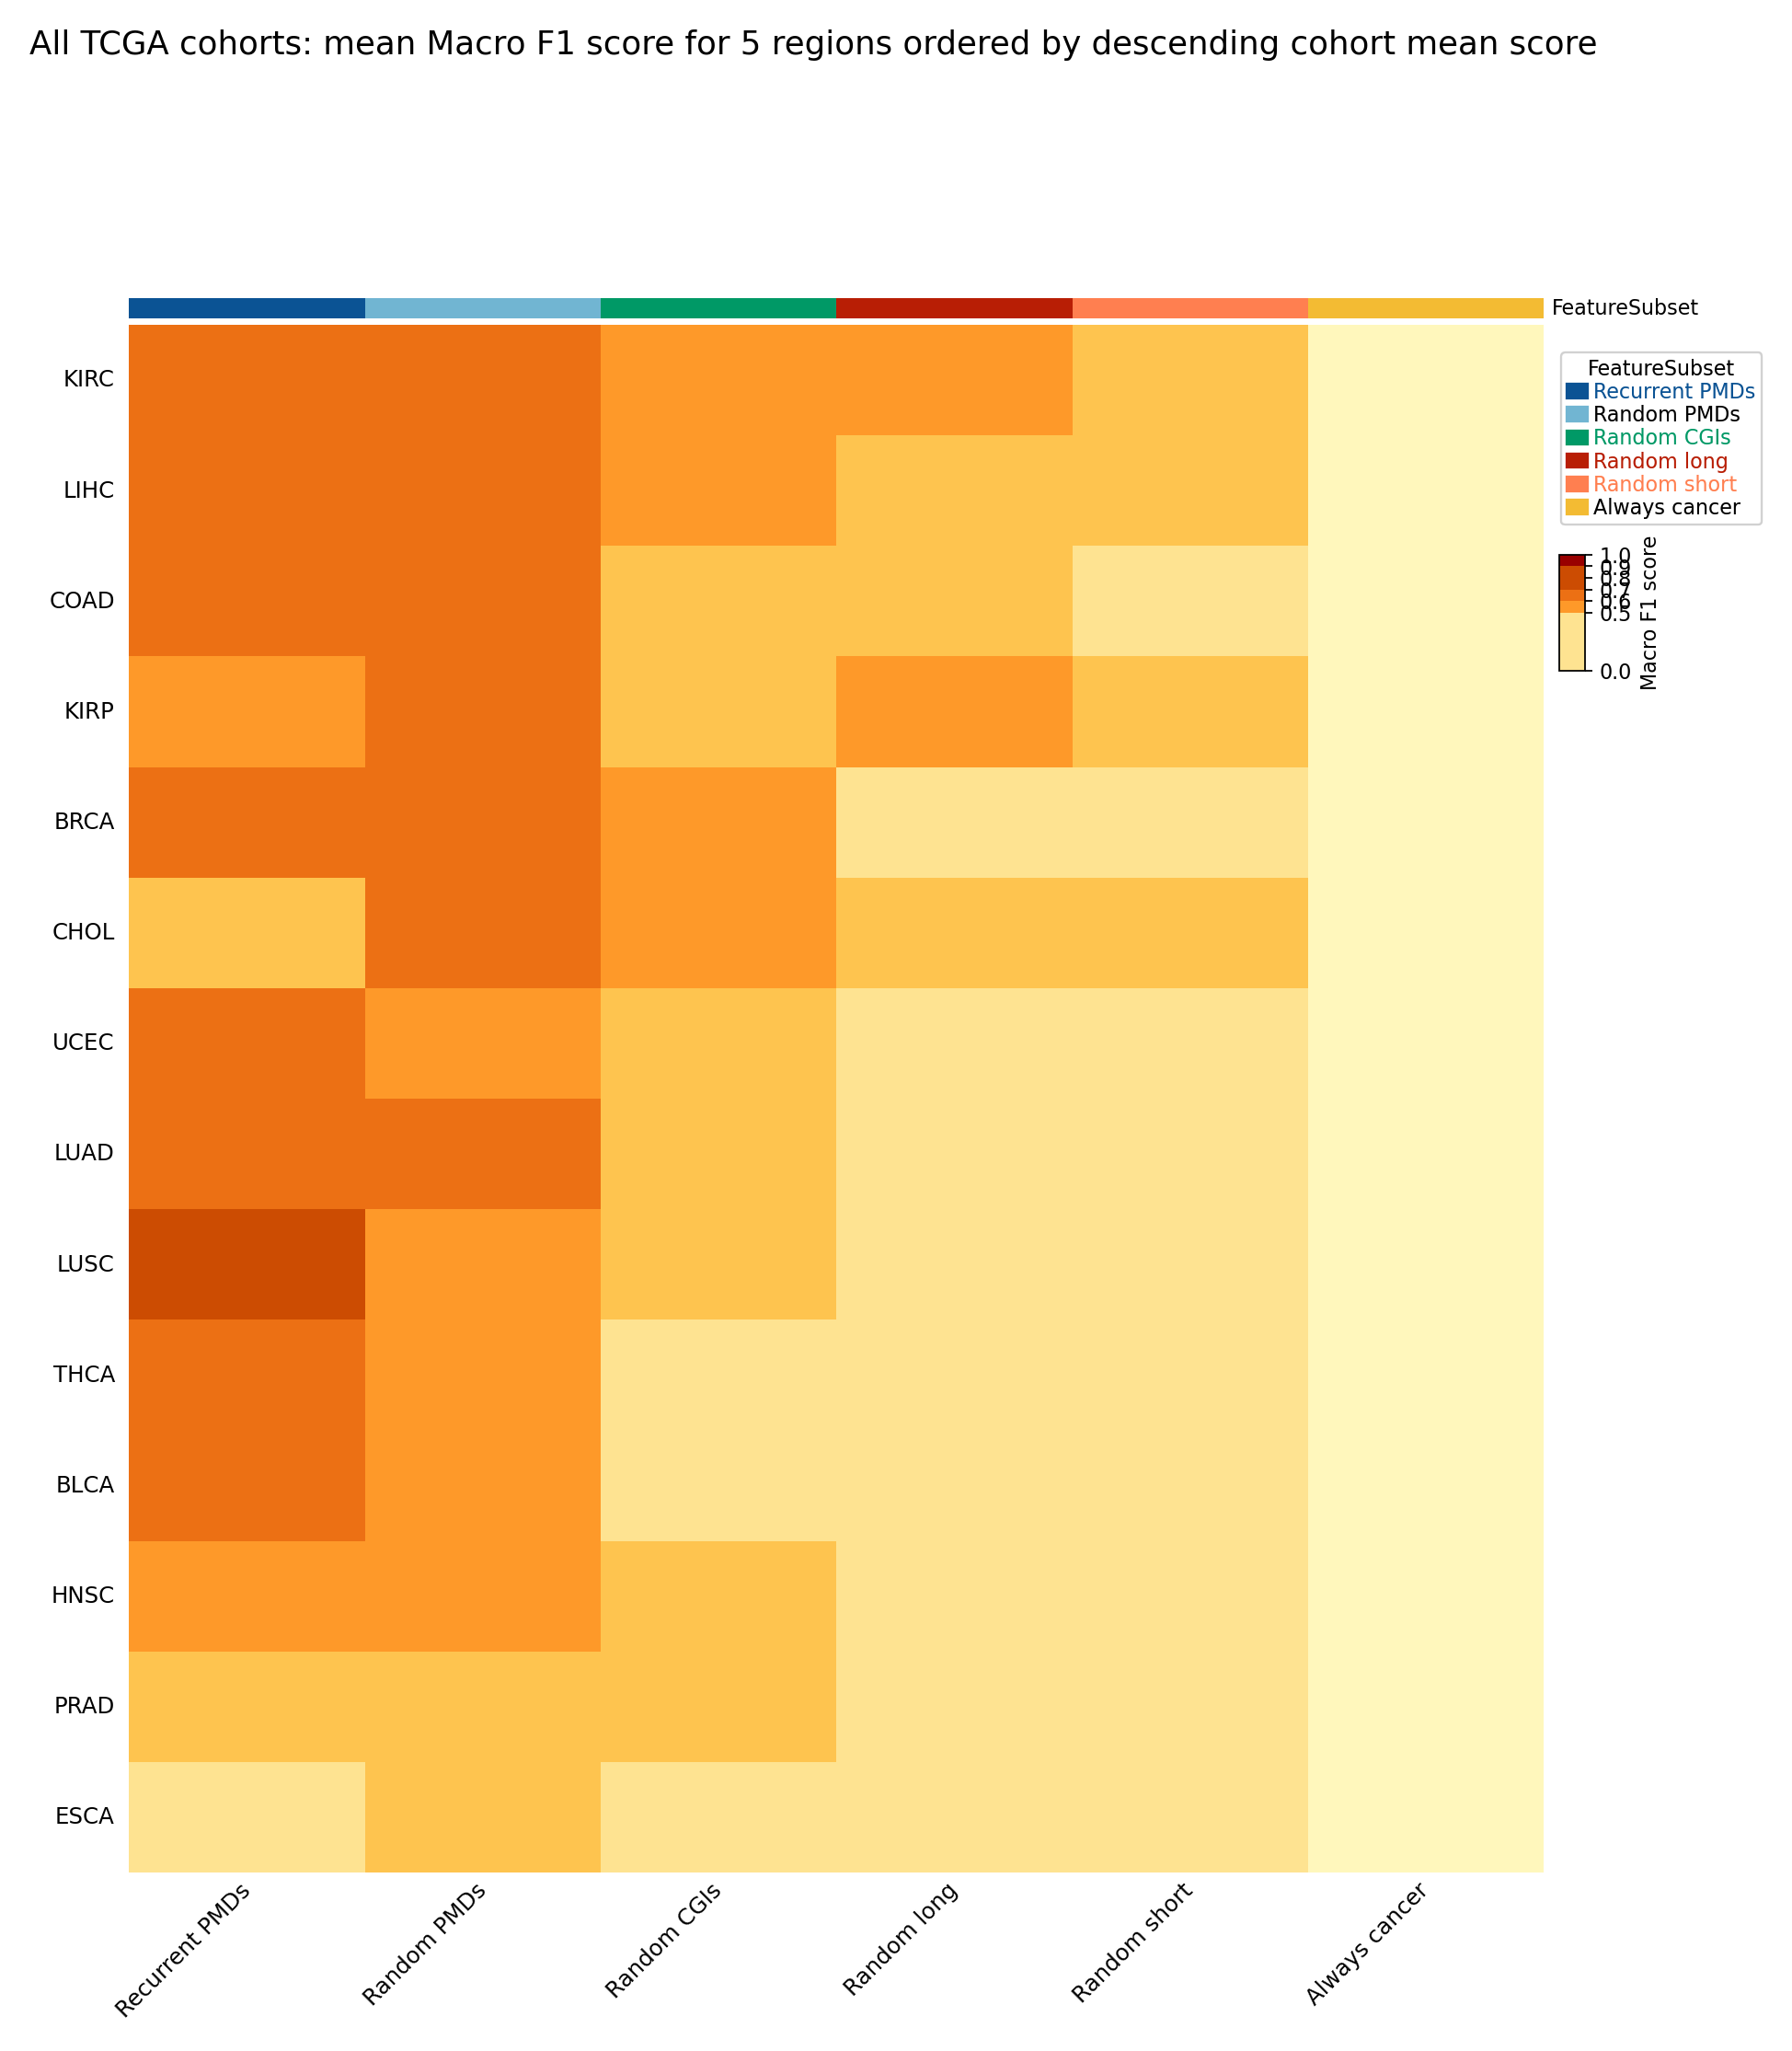

metric                                                      macro_f1
n_features                                                         5
backend                                             PyComplexHeatmap
n_cohorts                                                         14
n_feature_sets                                                     6
top_cancer                                                      KIRC
n_missing_cells                                                    0
figure_path        /uufs/chpc.utah.edu/common/home/clementm-group...
dtype: object

In [4]:
# All-cohort clustered summary heatmap
#
# Rerun this cell after changing the TCGA_COHORT_AVG_HEATMAP_* values above.

tcga_cohort_average_heatmap_output_summary = None
tcga_cohort_average_heatmap_matrix = None

tcga_cohort_average_heatmap_matrix, tcga_cohort_average_heatmap_metric = prepare_cohort_average_metric_heatmap_data(
    all_results_df,
    metric=TCGA_COHORT_AVG_HEATMAP_METRIC,
    n_features=TCGA_COHORT_AVG_HEATMAP_N_FEATURES,
    feature_set_order=TCGA_COHORT_AVG_HEATMAP_FEATURE_SET_ORDER,
    feature_set_labels=FEATURE_SET_LABELS,
    cohort_order=cohort_ids,
)
tcga_cohort_average_heatmap_plot = plot_cohort_average_metric_heatmap(
    tcga_cohort_average_heatmap_matrix,
    metric=tcga_cohort_average_heatmap_metric,
    n_features=TCGA_COHORT_AVG_HEATMAP_N_FEATURES,
    feature_set_palette={
        FEATURE_SET_LABELS.get(feature_set, feature_set): FEATURE_SET_PALETTE[feature_set]
        for feature_set in TCGA_COHORT_AVG_HEATMAP_FEATURE_SET_ORDER
        if feature_set in FEATURE_SET_PALETTE
    },
    cluster_rows=False,
    cluster_cols=False,
    tick_size=TCGA_PLOT_TICK_SIZE,
    figure_title_size=TCGA_FIGURE_TITLE_SIZE,
)
cohort_average_heatmap_stem = (
    TCGA_COHORT_AVG_HEATMAP_FILENAME_STEM.strip()
    if isinstance(TCGA_COHORT_AVG_HEATMAP_FILENAME_STEM, str) and TCGA_COHORT_AVG_HEATMAP_FILENAME_STEM.strip()
    else f"all_cohorts__clustered_mean_heatmap__{tcga_cohort_average_heatmap_metric}__n{TCGA_COHORT_AVG_HEATMAP_N_FEATURES:04d}"
)
tcga_cohort_average_heatmap_path = save_current_figure(
    FIG_OUT_DIR / f"{cohort_average_heatmap_stem}.png",
    fig=tcga_cohort_average_heatmap_plot.fig,
)
display_saved_figure(tcga_cohort_average_heatmap_path)
tcga_cohort_average_heatmap_output_summary = pd.Series(
    {
        "metric": tcga_cohort_average_heatmap_metric,
        "n_features": int(TCGA_COHORT_AVG_HEATMAP_N_FEATURES),
        "backend": str(tcga_cohort_average_heatmap_plot.backend),
        "n_cohorts": int(tcga_cohort_average_heatmap_plot.matrix.shape[0]),
        "n_feature_sets": int(tcga_cohort_average_heatmap_plot.matrix.shape[1]),
        "top_cancer": str(tcga_cohort_average_heatmap_matrix.index[0]),
        "n_missing_cells": int(tcga_cohort_average_heatmap_matrix.isna().sum().sum()),
        "figure_path": str(tcga_cohort_average_heatmap_path),
    }
)

tcga_cohort_average_heatmap_output_summary


In [5]:
# Per-fold diagnostic heatmap
#
# This keeps the saved-fold view as a separate diagnostic plot.
# Rerun this cell after changing the TCGA_HEATMAP_* values above.

tcga_metric_heatmap_output_summary = None
tcga_metric_heatmap_matrices = None
tcga_metric_heatmap_run_table = None
tcga_metric_heatmap_cancer_order = None

tcga_metric_heatmap_matrices, tcga_metric_heatmap_run_table, tcga_metric_heatmap_cancer_order, tcga_metric_heatmap_metric = prepare_per_fold_metric_heatmap_data(
    all_results_df,
    metric=TCGA_HEATMAP_METRIC,
    n_features=TCGA_HEATMAP_N_FEATURES,
    feature_set_order=TCGA_HEATMAP_FEATURE_SET_ORDER,
    feature_set_labels=FEATURE_SET_LABELS,
    cohort_order=cohort_ids,
    expand_feature_sets=TCGA_HEATMAP_EXPANDED_FEATURE_SETS,
)
tcga_metric_heatmap_grid = plot_per_fold_metric_heatmap_panels(
    tcga_metric_heatmap_matrices,
    cancer_order=tcga_metric_heatmap_cancer_order,
    metric=tcga_metric_heatmap_metric,
    n_features=TCGA_HEATMAP_N_FEATURES,
    feature_set_labels=FEATURE_SET_LABELS,
    title_size=TCGA_PLOT_TITLE_SIZE,
    label_size=TCGA_PLOT_LABEL_SIZE,
    tick_size=TCGA_PLOT_TICK_SIZE,
    figure_title_size=TCGA_FIGURE_TITLE_SIZE,
)
heatmap_stem = (
    TCGA_HEATMAP_FILENAME_STEM.strip()
    if isinstance(TCGA_HEATMAP_FILENAME_STEM, str) and TCGA_HEATMAP_FILENAME_STEM.strip()
    else f"all_cohorts__per_fold_diagnostic_heatmap__{tcga_metric_heatmap_metric}__n{TCGA_HEATMAP_N_FEATURES:04d}"
)
tcga_metric_heatmap_path = save_current_figure(
    FIG_OUT_DIR / f"{heatmap_stem}.png",
    fig=tcga_metric_heatmap_grid.fig,
)
display_saved_figure(tcga_metric_heatmap_path)
example_heatmap_matrix = next(iter(tcga_metric_heatmap_matrices.values()))
tcga_metric_heatmap_output_summary = pd.Series(
    {
        "metric": tcga_metric_heatmap_metric,
        "n_features": int(TCGA_HEATMAP_N_FEATURES),
        "backend": str(tcga_metric_heatmap_grid.backend),
        "n_cohorts": int(len(tcga_metric_heatmap_cancer_order)),
        "n_saved_runs": int(len(tcga_metric_heatmap_run_table)),
        "n_feature_sets": int(len(tcga_metric_heatmap_matrices)),
        "n_heatmap_rows": int(example_heatmap_matrix.shape[1]),
        "n_heatmap_columns": int(example_heatmap_matrix.shape[0]),
        "top_cancer": str(next(iter(tcga_metric_heatmap_grid.panel_cancer_orders.values()))[0]),
        "figure_path": str(tcga_metric_heatmap_path),
    }
)

tcga_metric_heatmap_output_summary


metric                                                        macro_f1
n_features                                                           5
backend                                               PyComplexHeatmap
n_cohorts                                                           14
n_saved_runs                                                       500
n_feature_sets                                                       6
n_heatmap_rows                                                      14
n_heatmap_columns                                                  500
top_cancer                                                        LUSC
figure_path          /uufs/chpc.utah.edu/common/home/clementm-group...
dtype: object

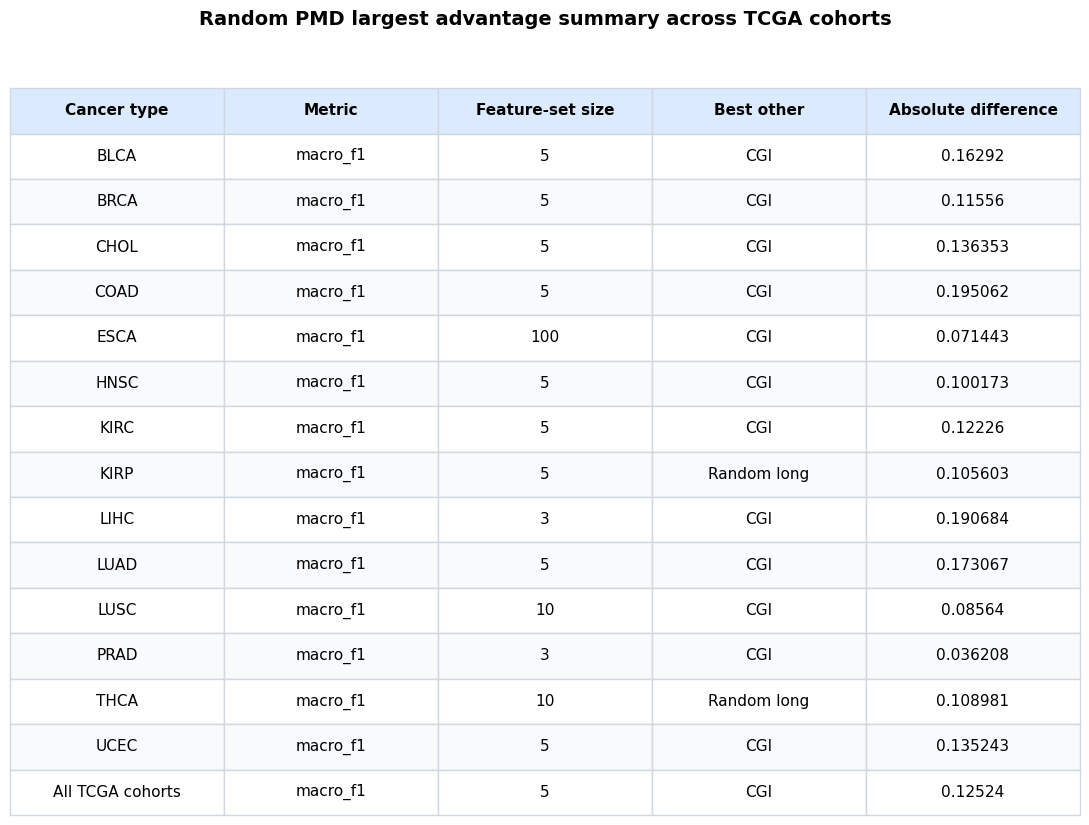

In [6]:
METRIC_NAME_ALIASES = {
    "f1": "macro_f1",
}
DEFAULT_COMPARISON_FEATURE_SETS = ["CGI", "Random short", "Random long"]


def resolve_summary_metric(metric: str = "f1") -> str:
    metric_name = METRIC_NAME_ALIASES.get(metric, metric)
    available_metrics = set(all_summaries_df["metric"].unique())
    if metric_name not in available_metrics:
        available = ", ".join(sorted(available_metrics))
        raise ValueError(f"Unknown metric {metric!r}. Available metrics: {available}")
    return metric_name


def find_random_pmd_largest_gap(
    summary_df: pd.DataFrame,
    metric: str = "f1",
    scope_col: str = "cohort_id",
    comparison_feature_sets: list[str] | None = None,
) -> pd.DataFrame:
    """Find the feature-set size with the largest Random PMD gap versus the requested comparators."""
    metric_name = resolve_summary_metric(metric)
    required_columns = {scope_col, "feature_set", "n_features", "metric", "mean"}
    missing_columns = required_columns.difference(summary_df.columns)
    if missing_columns:
        missing = ", ".join(sorted(missing_columns))
        raise ValueError(f"summary_df is missing required columns: {missing}")

    metric_summary = summary_df.loc[summary_df["metric"] == metric_name].copy()
    if metric_summary.empty:
        raise ValueError(f"No rows found for metric {metric_name!r}.")

    if comparison_feature_sets is None:
        comparison_feature_sets = DEFAULT_COMPARISON_FEATURE_SETS

    records = []
    for scope_value, scope_df in metric_summary.groupby(scope_col, sort=True):
        random_pmd = (
            scope_df.loc[scope_df["feature_set"] == "Random PMD", ["n_features", "mean"]]
            .rename(columns={"mean": "random_pmd_mean"})
        )
        best_other = (
            scope_df.loc[
                scope_df["feature_set"].isin(comparison_feature_sets),
                ["n_features", "feature_set", "mean"],
            ]
            .sort_values(["n_features", "mean", "feature_set"], ascending=[True, False, True])
            .drop_duplicates(subset=["n_features"], keep="first")
            .rename(columns={"feature_set": "best_other_feature_set", "mean": "best_other_mean"})
        )
        comparison = random_pmd.merge(best_other, on="n_features", how="inner")
        if comparison.empty:
            continue

        comparison["difference_best_other_minus_random_pmd"] = (
            comparison["best_other_mean"] - comparison["random_pmd_mean"]
        )
        comparison["absolute_difference"] = comparison[
            "difference_best_other_minus_random_pmd"
        ].abs()
        random_pmd_wins = comparison.loc[
            comparison["difference_best_other_minus_random_pmd"] < 0
        ].copy()
        if random_pmd_wins.empty:
            continue

        largest_gap = random_pmd_wins.sort_values(
            ["absolute_difference", "n_features"],
            ascending=[False, True],
        ).iloc[0]
        records.append(
            {
                scope_col: scope_value,
                "metric": metric_name,
                "n_features": int(largest_gap["n_features"]),
                "random_pmd_mean": float(largest_gap["random_pmd_mean"]),
                "best_other_feature_set": largest_gap["best_other_feature_set"],
                "best_other_mean": float(largest_gap["best_other_mean"]),
                "difference_best_other_minus_random_pmd": float(
                    largest_gap["difference_best_other_minus_random_pmd"]
                ),
                "absolute_difference": float(largest_gap["absolute_difference"]),
            }
        )

    return pd.DataFrame(records).sort_values(scope_col).reset_index(drop=True)


def plot_summary_table(table_df: pd.DataFrame, title: str, *, table_font_size: int = 11, title_size: int = 14) -> tuple[plt.Figure, plt.Axes]:
    n_rows = max(len(table_df), 1)
    fig_height = max(3.5, 0.45 * n_rows + 1.6)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    ax.axis("off")

    display_df = table_df.copy()
    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        cellLoc="center",
        loc="center",
        bbox=[0, 0, 1, 0.94],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(table_font_size)
    table.scale(1, 1.3)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor(ANNOTATION_COLORS["tcga_table_edge"])
        if row == 0:
            cell.set_facecolor(ANNOTATION_COLORS["tcga_table_header_fill"])
            cell.set_text_props(weight="bold")
        elif row % 2 == 0:
            cell.set_facecolor(ANNOTATION_COLORS["tcga_table_alt_fill"])
        else:
            cell.set_facecolor(ANNOTATION_COLORS["tcga_table_base_fill"])

    ax.set_title(title, fontsize=title_size, weight="bold", pad=12)
    fig.tight_layout()
    return fig, ax


per_cancer_random_pmd_gaps = find_random_pmd_largest_gap(all_summaries_df)
per_cancer_random_pmd_gaps["scope_label"] = per_cancer_random_pmd_gaps["cohort_id"].map(format_cohort_label)

aggregate_random_pmd_gaps = find_random_pmd_largest_gap(
    aggregate_line_summary.assign(scope="Aggregate"),
    scope_col="scope",
)
aggregate_random_pmd_gaps["scope_label"] = "All TCGA cohorts"

random_pmd_gap_summary = pd.concat(
    [
        per_cancer_random_pmd_gaps.rename(columns={"cohort_id": "scope"}),
        aggregate_random_pmd_gaps,
    ],
    ignore_index=True,
)
random_pmd_gap_summary = random_pmd_gap_summary[
    [
        "scope",
        "scope_label",
        "metric",
        "n_features",
        "random_pmd_mean",
        "best_other_feature_set",
        "best_other_mean",
        "difference_best_other_minus_random_pmd",
        "absolute_difference",
    ]
]

random_pmd_gap_table = random_pmd_gap_summary.rename(
    columns={
        "scope_label": "Cancer type",
        "metric": "Metric",
        "n_features": "Feature-set size",
        "best_other_feature_set": "Best other",
        "absolute_difference": "Absolute difference",
    }
)[
    [
        "Cancer type",
        "Metric",
        "Feature-set size",
        "Best other",
        "Absolute difference",
    ]
]
random_pmd_gap_table["Absolute difference"] = random_pmd_gap_table["Absolute difference"].round(6)
random_pmd_gap_table_figure, random_pmd_gap_table_axis = plot_summary_table_styled(
    random_pmd_gap_table,
    title="Random PMD largest advantage summary across TCGA cohorts",
)
plt.show()


In [7]:
random_pmd_gap_table["Absolute difference"].mean()

np.float64(0.12429580000000001)

In [8]:
LOOKUP_CANCER_TYPE = "BRCA"
LOOKUP_N_FEATURES = 5
LOOKUP_METRIC = "f1"


def resolve_lookup_scope(cancer_type: str) -> tuple[str, str]:
    cancer_label = str(cancer_type).strip()
    normalized = cancer_label.casefold()
    if normalized in {"aggregate", "all tcga cohorts", "all cohorts"}:
        return "Aggregate", "All TCGA cohorts"

    available_cohorts = sorted(all_summaries_df["cohort_id"].dropna().astype(str).unique())
    cohort_by_label = {format_cohort_label(cohort_id).casefold(): cohort_id for cohort_id in available_cohorts}
    if normalized in cohort_by_label:
        cohort_id = cohort_by_label[normalized]
        return cohort_id, format_cohort_label(cohort_id)

    if cancer_label in available_cohorts:
        return cancer_label, format_cohort_label(cancer_label)

    prefixed = cancer_label if cancer_label.upper().startswith("TCGA-") else f"TCGA-{cancer_label.upper()}"
    if prefixed in available_cohorts:
        return prefixed, format_cohort_label(prefixed)

    available_labels = ", ".join(format_cohort_label(cohort_id) for cohort_id in available_cohorts)
    raise ValueError(
        f"Unknown cancer type {cancer_type!r}. Use one of: {available_labels}, or 'Aggregate'."
    )


def lookup_average_metric_for_cancer(
    cancer_type: str,
    n_features: int,
    metric: str = "f1",
) -> pd.DataFrame:
    metric_name = resolve_summary_metric(metric)
    scope_value, scope_label = resolve_lookup_scope(cancer_type)

    if scope_value == "Aggregate":
        lookup_df = aggregate_line_summary.assign(scope="Aggregate")
        scope_col = "scope"
    else:
        lookup_df = all_summaries_df.copy()
        scope_col = "cohort_id"

    filtered = lookup_df.loc[
        (lookup_df[scope_col] == scope_value)
        & (lookup_df["metric"] == metric_name)
        & (lookup_df["n_features"] == n_features)
    ].copy()
    if filtered.empty:
        raise ValueError(
            f"No rows found for cancer_type={cancer_type!r}, n_features={n_features}, metric={metric_name!r}."
        )

    filtered["Cancer type"] = scope_label
    filtered["Metric"] = metric_name
    filtered["Feature size"] = int(n_features)
    filtered["Feature set"] = filtered["feature_set"]
    filtered["Average metric"] = filtered["mean"].round(6)

    return filtered[
        ["Cancer type", "Metric", "Feature size", "Feature set", "Average metric"]
    ].sort_values(["Average metric", "Feature set"], ascending=[False, True]).reset_index(drop=True)


lookup_metric_table = lookup_average_metric_for_cancer(
    cancer_type=LOOKUP_CANCER_TYPE,
    n_features=LOOKUP_N_FEATURES,
    metric=LOOKUP_METRIC,
)
lookup_metric_table


,Cancer type,Metric,Feature size,Feature set,Average metric
0,BRCA,macro_f1,5,PMD,0.849735
1,BRCA,macro_f1,5,Random PMD,0.832732
2,BRCA,macro_f1,5,CGI,0.717172
3,BRCA,macro_f1,5,Random short,0.587582
4,BRCA,macro_f1,5,Random long,0.560849
5,BRCA,macro_f1,5,Always cancer,0.474820


In [9]:
TCGA_SAMPLE_MANIFEST_PATH = TCGA_CLASSIFICATION_RESULTS_DIR / "manifests" / "tcga_samples.tsv"


def load_used_tcga_samples() -> pd.DataFrame:
    sample_manifest = pd.read_csv(TCGA_SAMPLE_MANIFEST_PATH, sep="	").copy()
    used_cohort_ids = discover_saved_cohorts(RESULTS_DIR)
    used_samples = sample_manifest.loc[
        sample_manifest["project_id"].astype(str).isin(used_cohort_ids)
    ].copy()
    if used_samples.empty:
        raise ValueError("No used TCGA samples were found for the saved cohorts.")
    return used_samples.drop_duplicates(subset=["sample_id"]).reset_index(drop=True)


def summarize_used_samples_for_pies(used_samples: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    cancer_counts = (
        used_samples.groupby("project_id", as_index=False)
        .size()
        .rename(columns={"size": "n_samples"})
        .sort_values(["n_samples", "project_id"], ascending=[False, True])
        .reset_index(drop=True)
    )
    tissue_counts = (
        used_samples.groupby("sample_type", as_index=False)
        .size()
        .rename(columns={"size": "n_samples"})
        .sort_values(["n_samples", "sample_type"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return cancer_counts, tissue_counts


def make_pie_labels(values: pd.Series, labels: pd.Series) -> list[str]:
    return [f"{label}\nN={int(value)}" for label, value in zip(labels, values)]


def autopct_for_counts(values: pd.Series):
    total = float(values.sum())

    def _formatter(pct: float) -> str:
        if pct < 0.8:
            return ""
        count = int(round(total * pct / 100.0))
        return f"{pct:.1f}%"

    return _formatter


def plot_used_sample_distribution_pies(
    cancer_counts: pd.DataFrame,
    tissue_counts: pd.DataFrame,
    *,
    label_font_size: int = 8,
    axes_title_size: int = 14,
    figure_title_size: int = 16,
) -> tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

    cancer_colors = ordered_palette(
        cancer_counts["project_id"].astype(str).tolist(),
        get_categorical_color_map(cancer_counts["project_id"].astype(str).tolist(), sequence_name="tab20"),
    )
    tissue_colors = ordered_palette(
        tissue_counts["sample_type"].astype(str).tolist(),
        get_categorical_color_map(tissue_counts["sample_type"].astype(str).tolist(), sequence_name="set2"),
    )

    axes[0].pie(
        cancer_counts["n_samples"],
        labels=make_pie_labels(cancer_counts["n_samples"], cancer_counts["project_id"]),
        colors=cancer_colors,
        startangle=90,
        counterclock=False,
        labeldistance=1.10,
        pctdistance=0.72,
        autopct=autopct_for_counts(cancer_counts["n_samples"]),
        textprops={"fontsize": label_font_size},
        wedgeprops={"linewidth": 0.8, "edgecolor": NEUTRAL_COLORS["white"]},
    )
    axes[0].set_title("Samples used by cancer type", fontsize=axes_title_size, weight="bold")

    axes[1].pie(
        tissue_counts["n_samples"],
        labels=make_pie_labels(tissue_counts["n_samples"], tissue_counts["sample_type"]),
        colors=tissue_colors,
        startangle=90,
        counterclock=False,
        labeldistance=1.10,
        pctdistance=0.72,
        autopct=autopct_for_counts(tissue_counts["n_samples"]),
        textprops={"fontsize": label_font_size},
        wedgeprops={"linewidth": 0.8, "edgecolor": NEUTRAL_COLORS["white"]},
    )
    axes[1].set_title("Samples used by tissue type", fontsize=axes_title_size, weight="bold")

    total_samples = int(cancer_counts["n_samples"].sum())
    fig.suptitle(
        f"TCGA samples used in saved classification cohorts (N={total_samples})",
        fontsize=figure_title_size,
        weight="bold",
    )
    return fig, axes


used_tcga_samples = load_used_tcga_samples()
used_cancer_counts, used_tissue_counts = summarize_used_samples_for_pies(used_tcga_samples)
used_sample_distribution_figure, used_sample_distribution_axes = plot_used_sample_distribution_pies_styled(
    used_cancer_counts,
    used_tissue_counts,
)
used_sample_distribution_path = save_current_figure(
    FIG_OUT_DIR / "all_cohorts__used_sample_distribution_pies.png",
    fig=used_sample_distribution_figure,
)
used_sample_distribution_summary = pd.Series({
    "n_used_samples": int(len(used_tcga_samples)),
    "n_used_cancer_types": int(used_cancer_counts.shape[0]),
    "n_used_tissue_types": int(used_tissue_counts.shape[0]),
    "figure_path": str(used_sample_distribution_path),
})


In [11]:
# Export the exact deduplicated sample set used by the pie charts above.
ANALYZED_TCGA_SAMPLE_MANIFEST_PATH = TCGA_SAMPLE_MANIFEST_PATH.with_name("analyzed_tcga_samples.tsv")
analyzed_tcga_samples = used_tcga_samples.copy()

expected_n_samples = int(used_cancer_counts["n_samples"].sum())
if len(analyzed_tcga_samples) != expected_n_samples:
    raise ValueError(
        "Analyzed manifest row count does not match the sample count shown in the pie charts: "
        f"{len(analyzed_tcga_samples):,} != {expected_n_samples:,}."
    )

analyzed_tcga_samples.to_csv(
    ANALYZED_TCGA_SAMPLE_MANIFEST_PATH,
    columns=["sample_id", "project_id", "project_descriptor", "sample_type"],
    sep="\t",
    index=False,
)
pd.Series({
    "n_analyzed_samples": int(len(analyzed_tcga_samples)),
    "manifest_path": str(ANALYZED_TCGA_SAMPLE_MANIFEST_PATH),
})


n_analyzed_samples                                                 5892
manifest_path         /uufs/chpc.utah.edu/common/home/clementm-group...
dtype: object